In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h 
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pt100_acid.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.52,15
,3000,0,0.52,7
,3000,0,0.51,3
,3000,0,0.45,7


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   774.03    41.22
p_loo       11.80        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



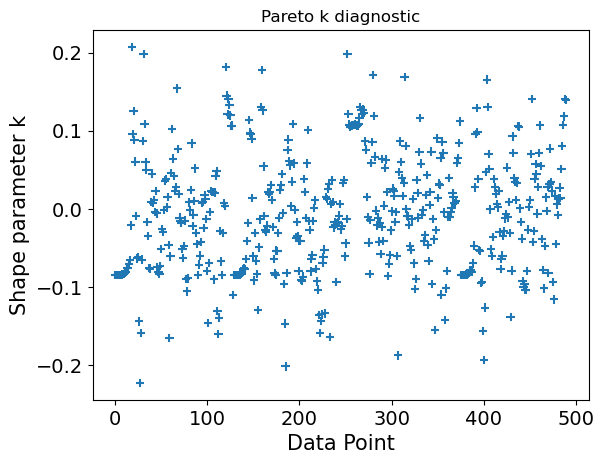

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.074  0.003  -0.080   -0.068      0.000    0.000    1354.0    1642.0    1.0
deltaG4_0   0.911  0.003   0.906    0.917      0.000    0.000    1345.0    1868.0    1.0
Gact2_0     0.688  0.001   0.686    0.691      0.000    0.000    1768.0    2256.0    1.0
sigma_rel   0.400  0.037   0.334    0.470      0.001    0.001    1870.0    2235.0    1.0
sigma_base  0.007  0.001   0.006    0.008      0.000    0.000    3528.0    2795.0    1.0
exponent    1.595  0.096   1.417    1.777      0.002    0.002    1689.0    1940.0    1.0


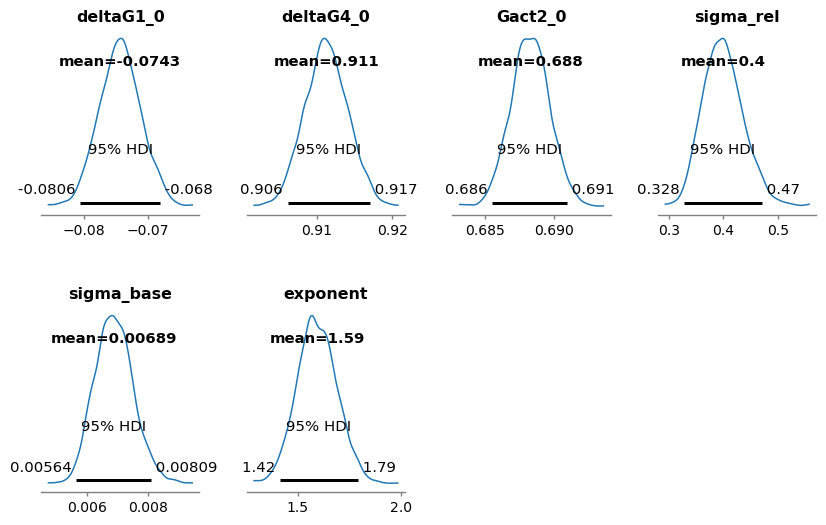

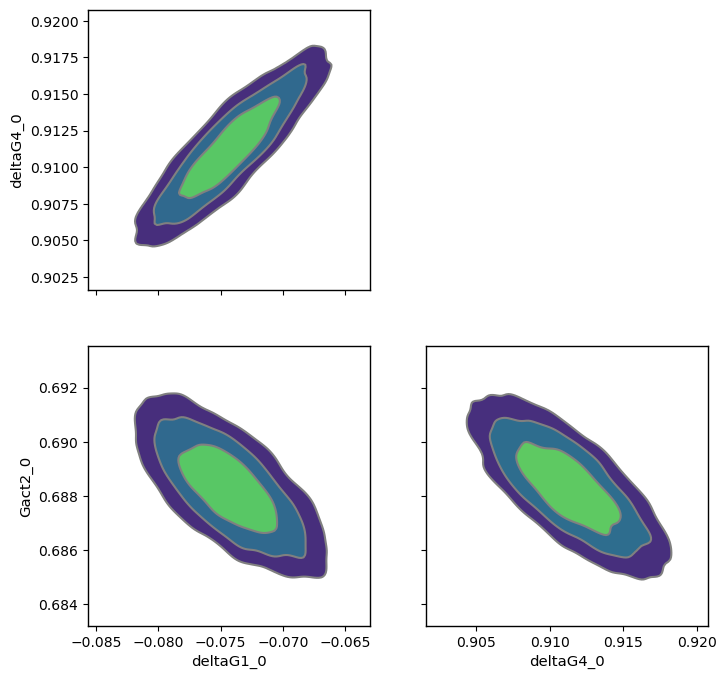

Sampling: [rate]


rate: 0.612


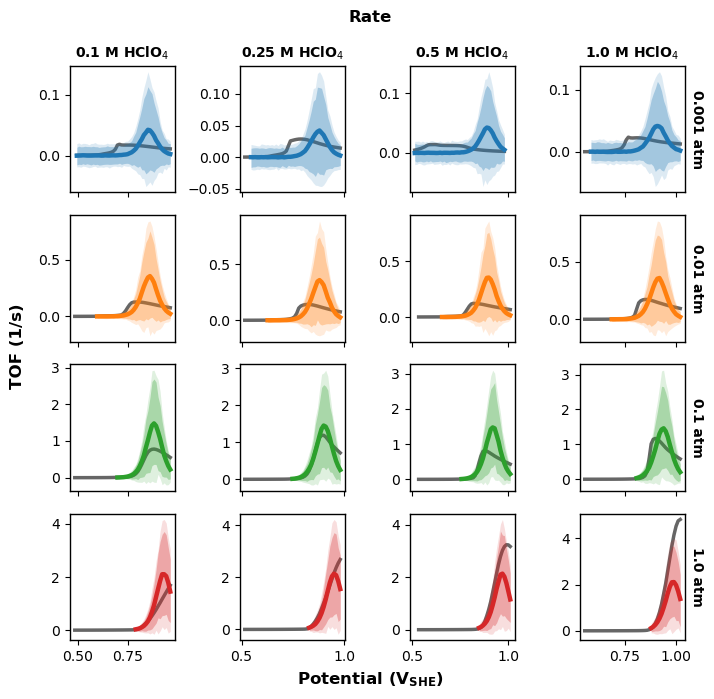

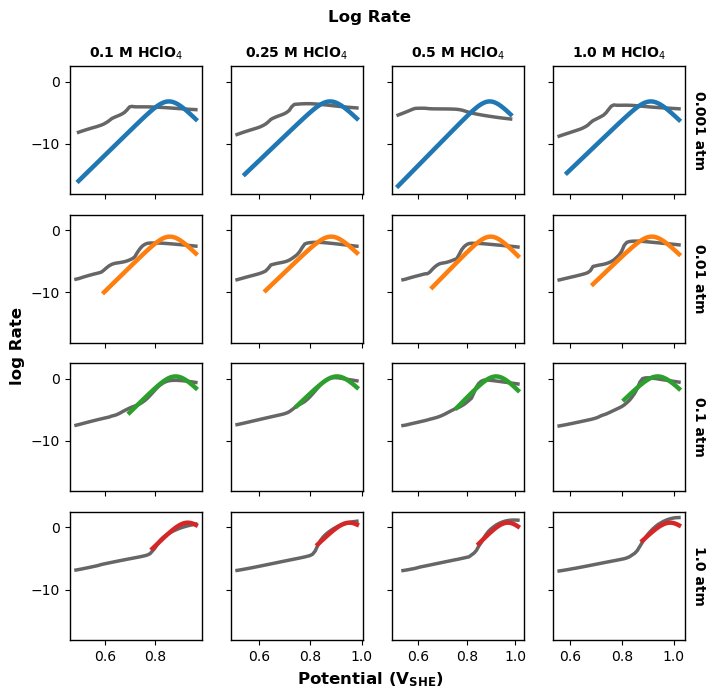

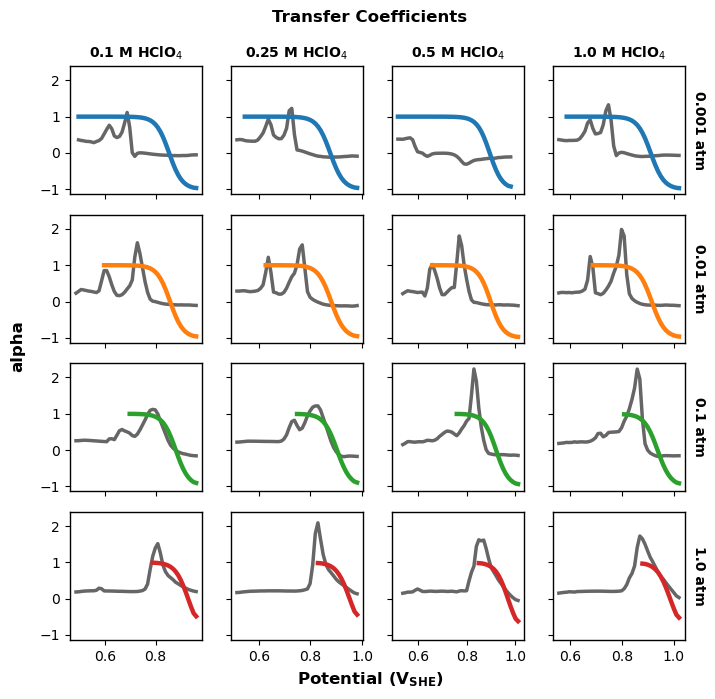

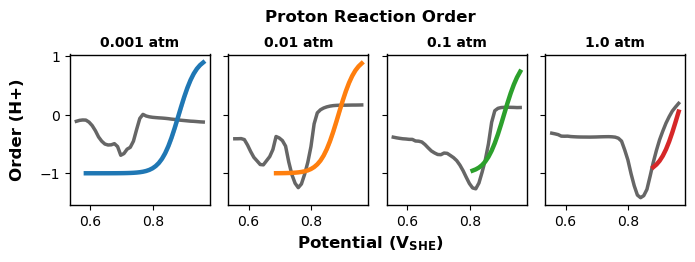

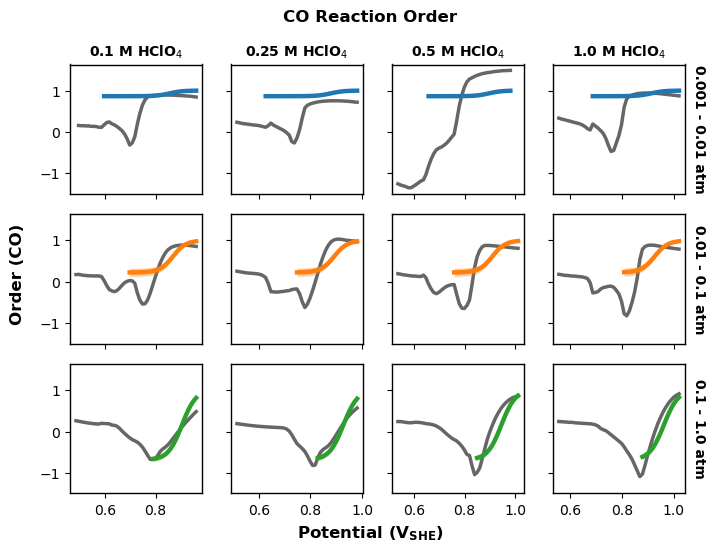

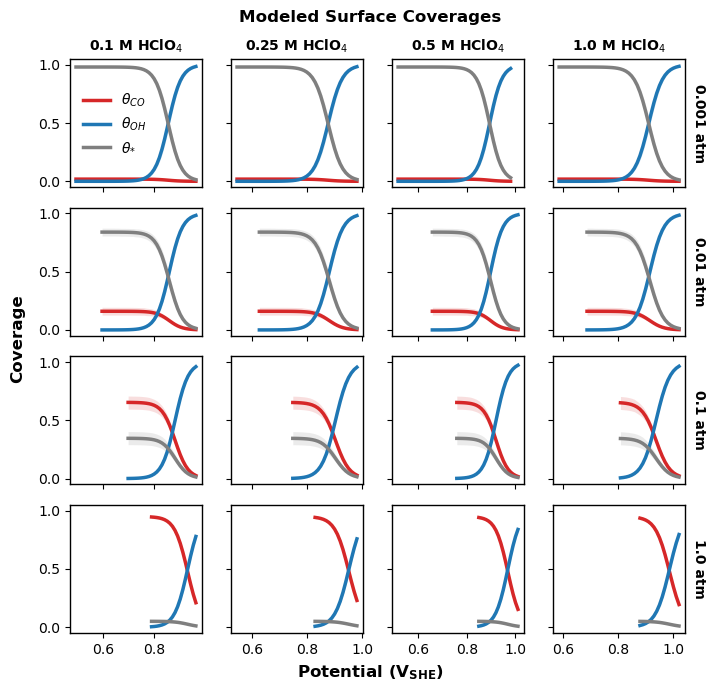

In [2]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.15,31
,3000,0,0.19,63
,3000,0,0.17,31
,3000,0,0.16,31


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   861.34    42.30
p_loo       11.05        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



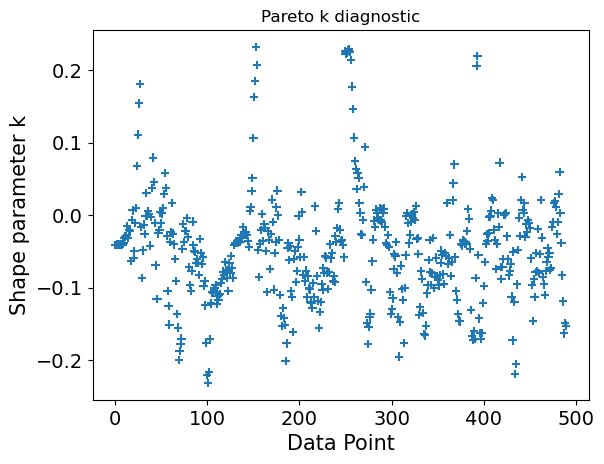

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.160  0.009  -0.177   -0.142      0.000    0.000     654.0    1066.0   1.00
deltaG4_0   0.849  0.011   0.829    0.870      0.000    0.000     615.0     970.0   1.00
Gact2_0     1.249  0.014   1.219    1.273      0.001    0.000     512.0     751.0   1.01
beta_2      0.557  0.016   0.526    0.586      0.001    0.000     521.0     761.0   1.01
sigma_rel   0.365  0.034   0.304    0.428      0.001    0.001    2721.0    2417.0   1.00
sigma_base  0.003  0.001   0.002    0.004      0.000    0.000    2605.0    2937.0   1.00
exponent    1.689  0.071   1.555    1.817      0.001    0.001    2641.0    2592.0   1.00


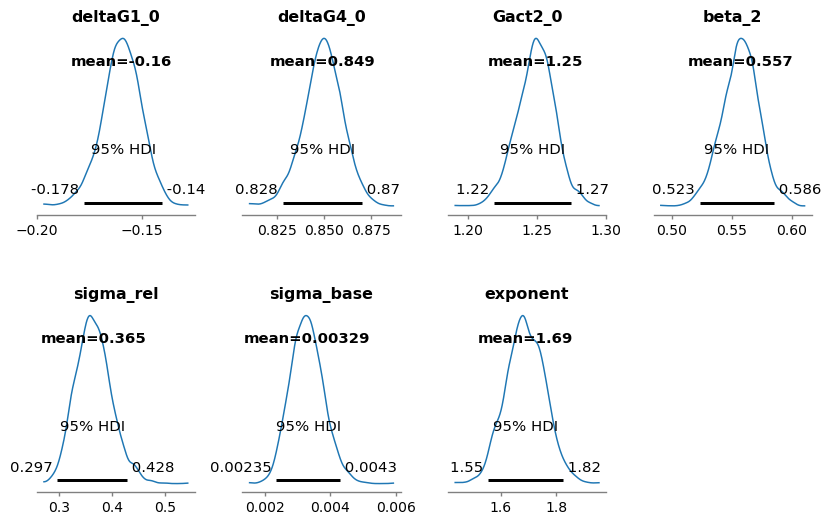

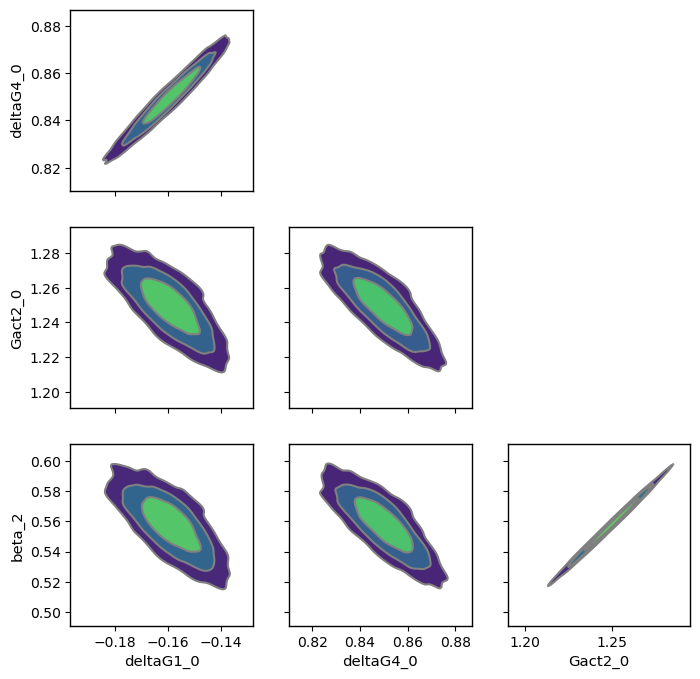

Sampling: [rate]


rate: 0.809


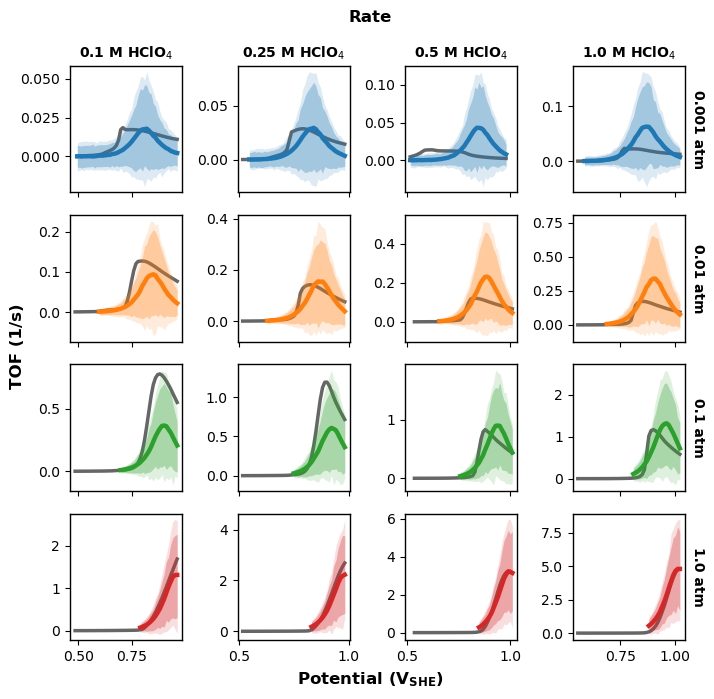

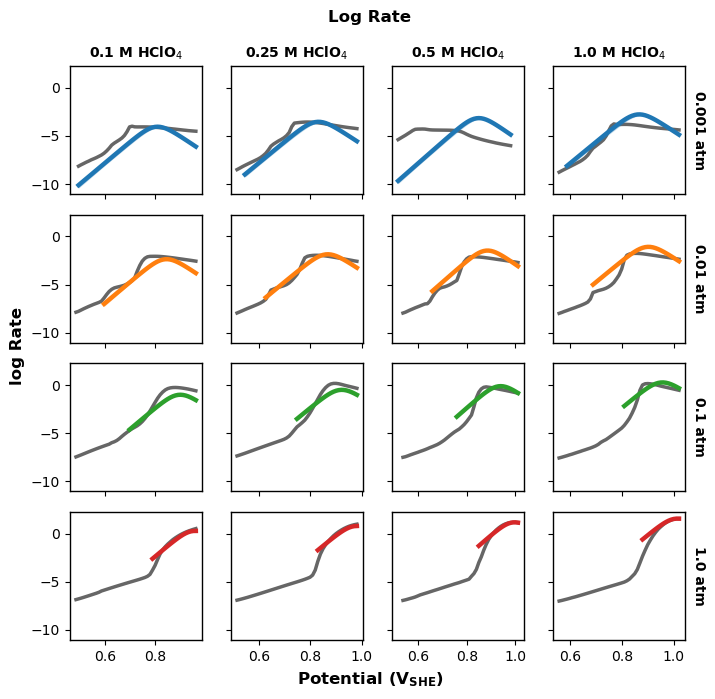

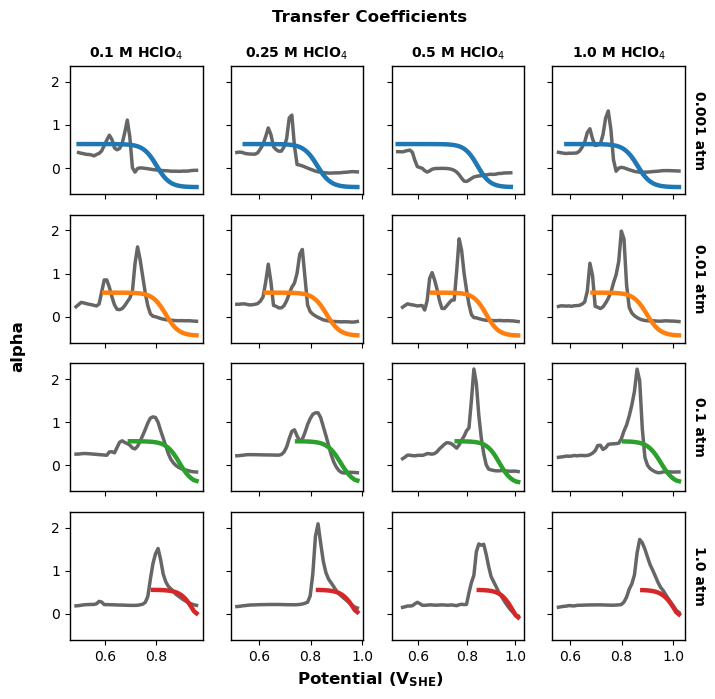

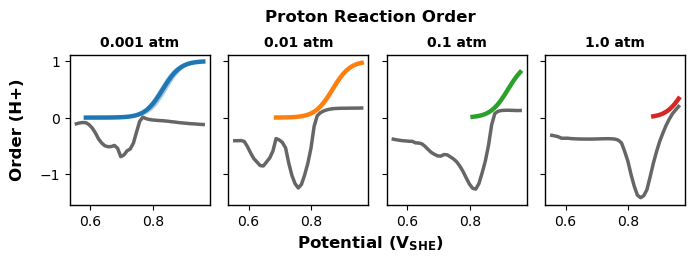

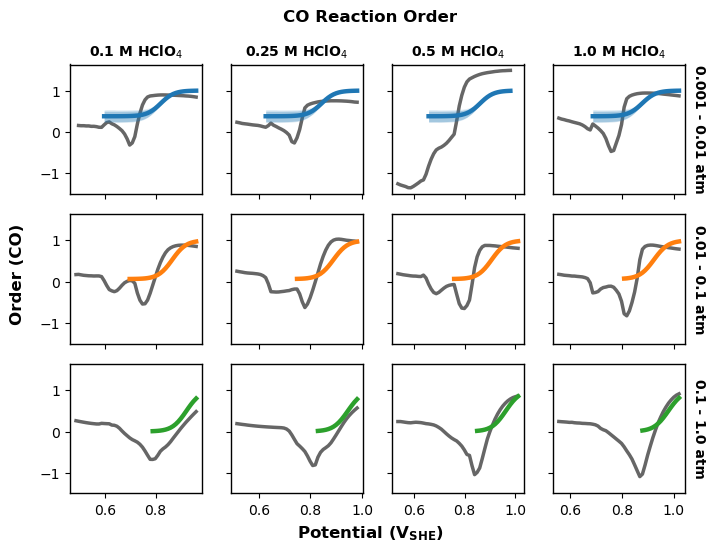

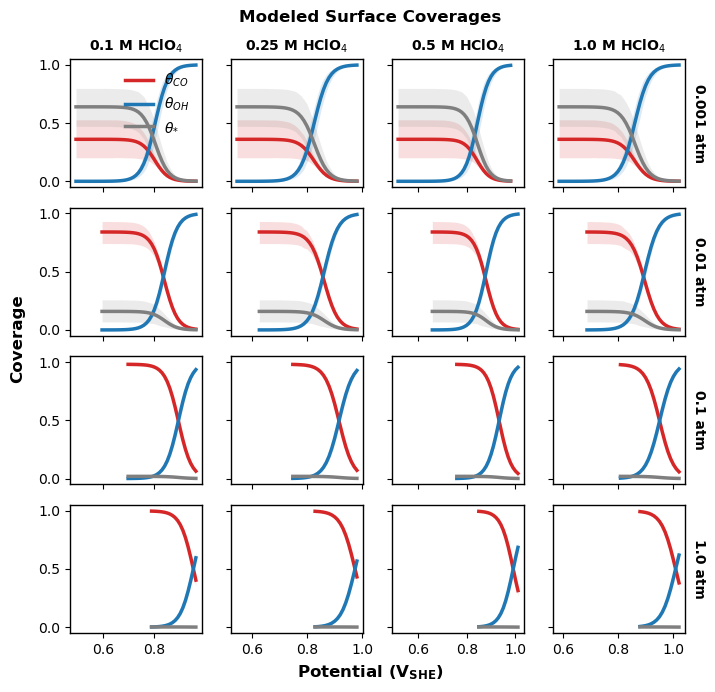

In [3]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,15
,3000,0,0.15,95
,3000,0,0.15,127
,3000,0,0.13,63


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   907.95    38.09
p_loo       11.31        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



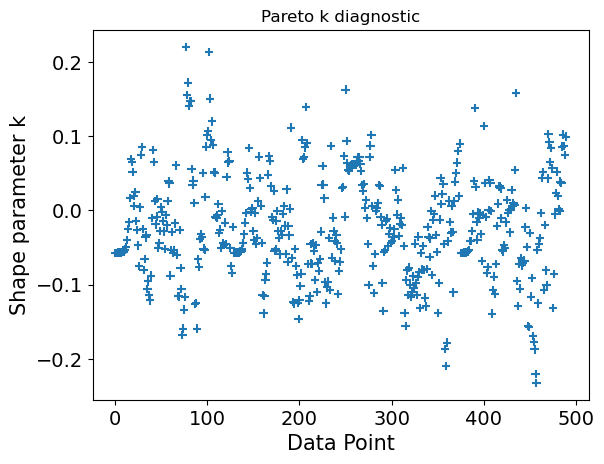

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.097  0.003  -0.103   -0.091      0.000    0.000    1155.0    2103.0    1.0
deltaG4_0   0.884  0.003   0.878    0.890      0.000    0.000    1677.0    2149.0    1.0
Gact2_LH_0  0.713  0.003   0.709    0.718      0.000    0.000     993.0    1851.0    1.0
Gact2_ER_0  1.508  0.034   1.448    1.572      0.001    0.001     505.0     675.0    1.0
beta_2      0.830  0.035   0.767    0.897      0.002    0.001     509.0     680.0    1.0
sigma_rel   0.247  0.023   0.203    0.288      0.000    0.000    2615.0    2730.0    1.0
sigma_base  0.006  0.001   0.005    0.007      0.000    0.000    3551.0    2576.0    1.0
exponent    1.444  0.087   1.279    1.598      0.002    0.001    2413.0    2429.0    1.0


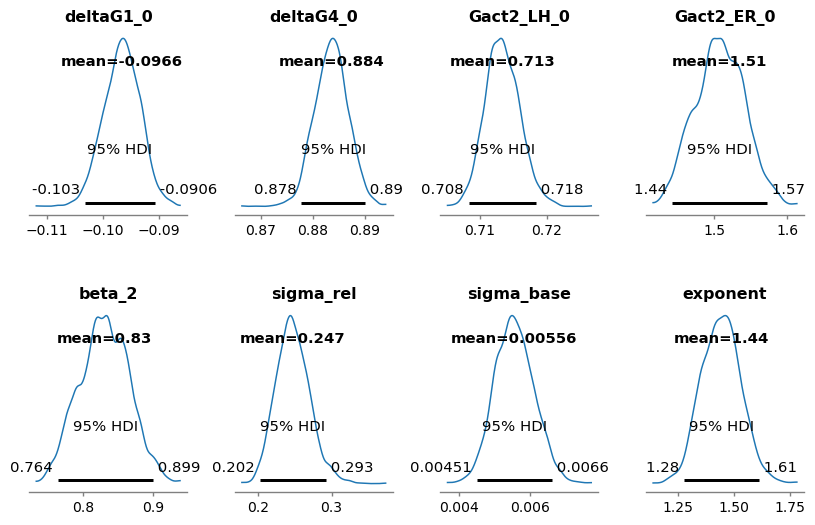

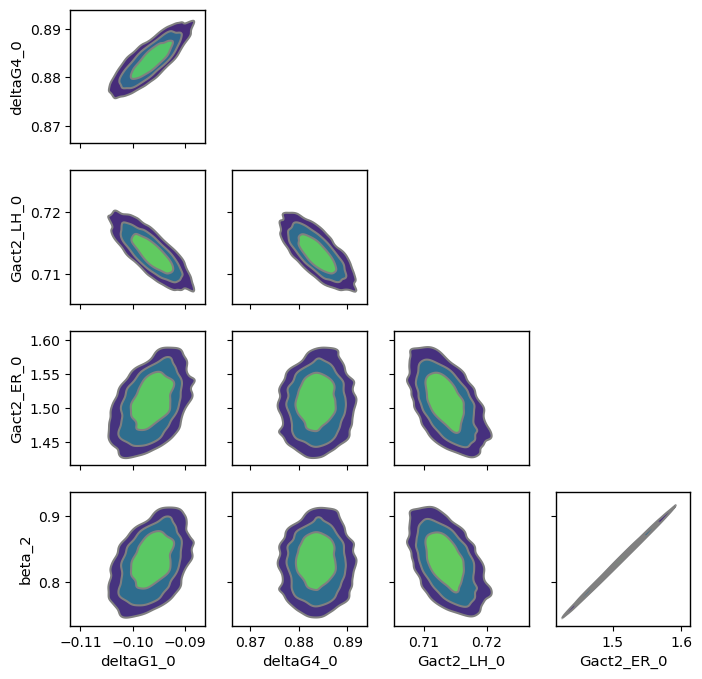

Sampling: [rate]


rate: 0.892


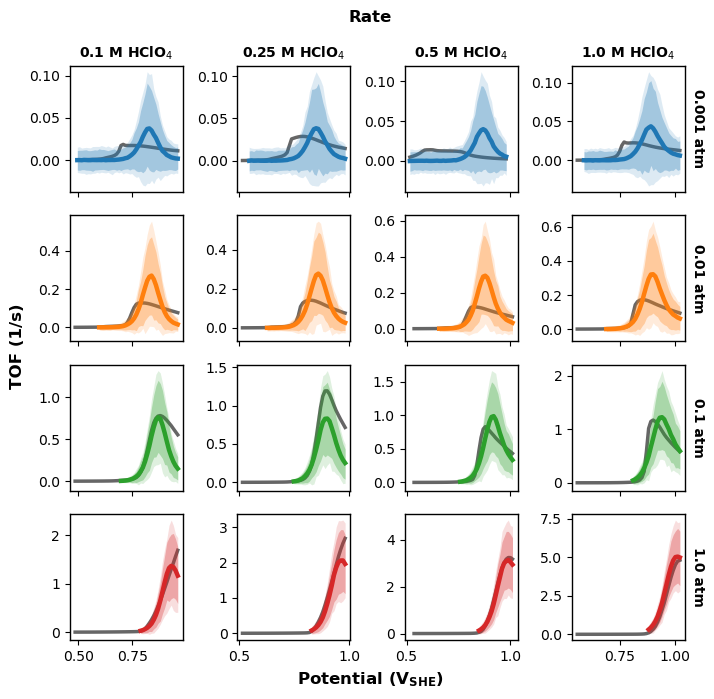

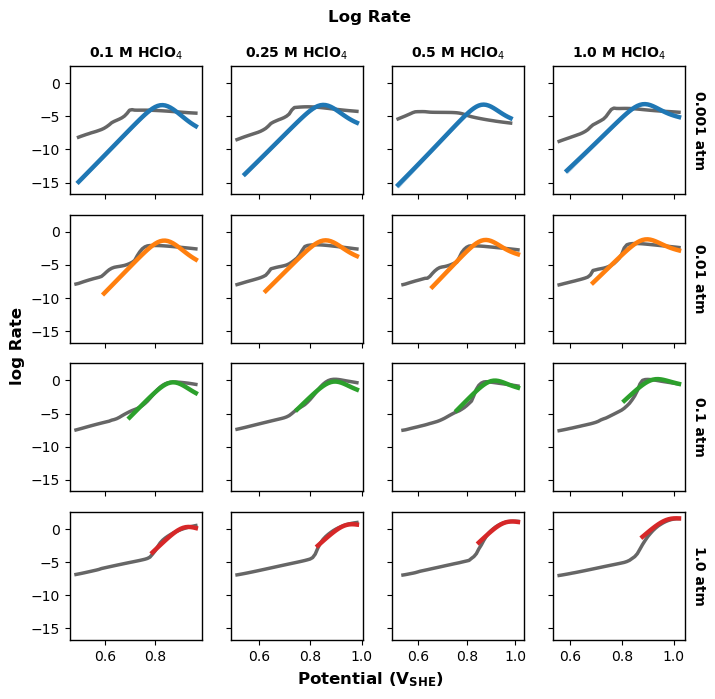

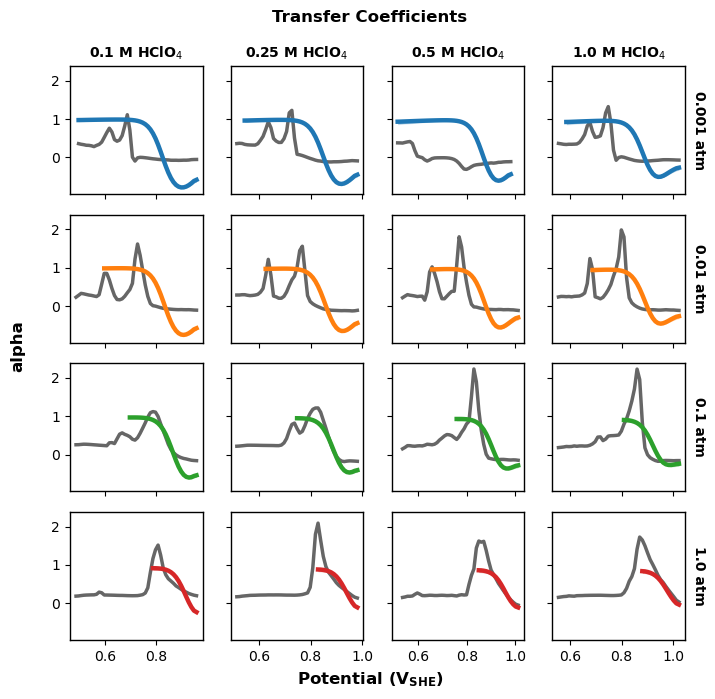

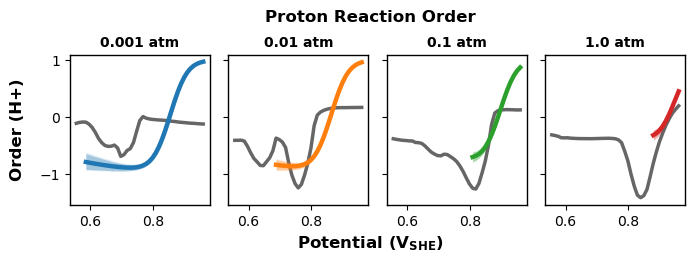

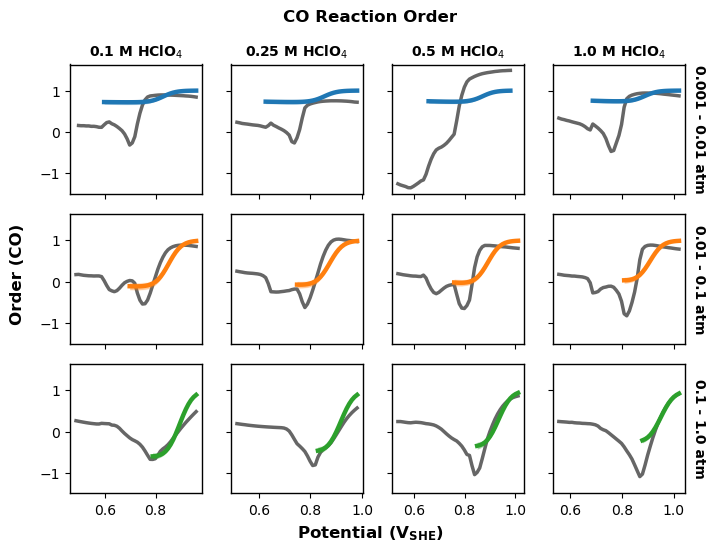

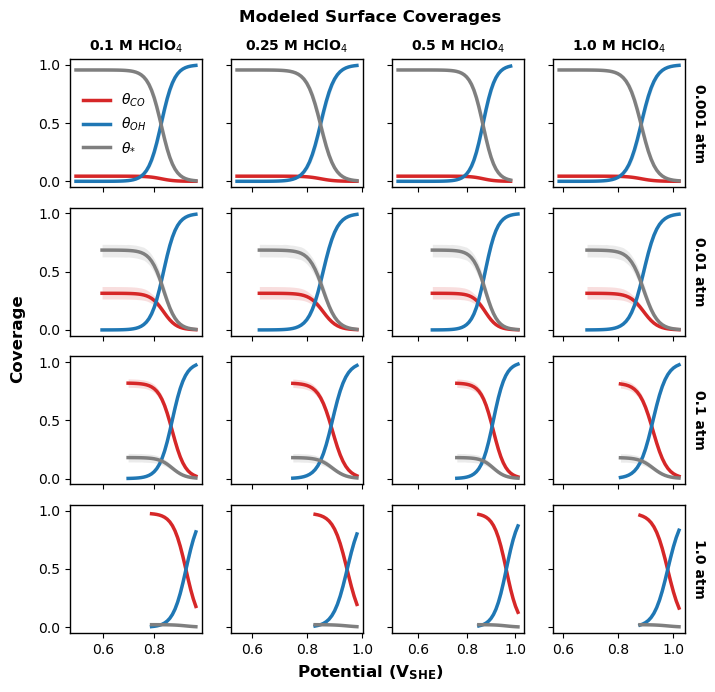

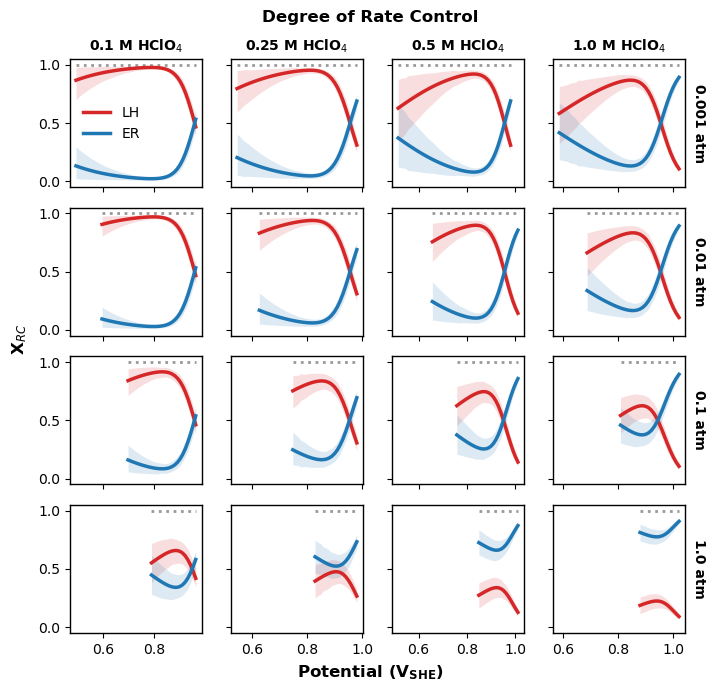

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_ER = log_k2_ER + log_theta_CO 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate) 

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_2)

ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_2)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)
plot_drc(ER_2, trace_ER_LH_2, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['LH', 'ER'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact'})

# LH 2 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.16,31
,3000,0,0.17,15
,3000,0,0.16,7
,3000,0,0.16,63


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   796.97    37.62
p_loo       16.67        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



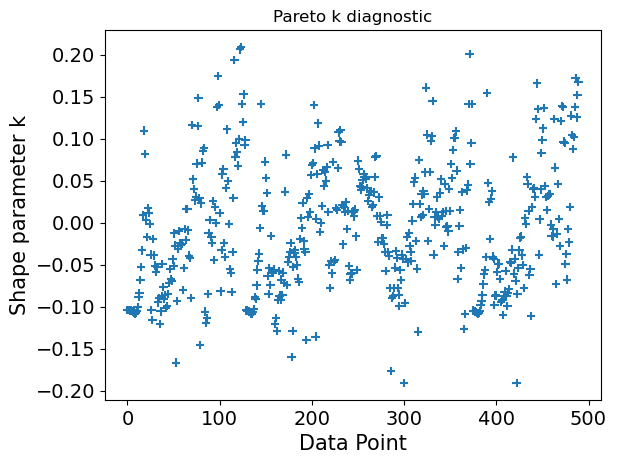

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.037  0.004  -0.045   -0.029      0.000    0.000    1709.0    1928.0   1.00
deltaG4_0   0.917  0.003   0.912    0.922      0.000    0.000    2402.0    2359.0   1.00
Gact2_0     0.671  0.003   0.665    0.675      0.000    0.000    1747.0    2005.0   1.00
Gact4_0     1.168  0.028   1.114    1.220      0.001    0.001     648.0     795.0   1.01
beta_4      0.519  0.030   0.460    0.573      0.001    0.001     661.0     824.0   1.01
sigma_rel   0.231  0.019   0.195    0.267      0.000    0.000    2511.0    2724.0   1.00
sigma_base  0.006  0.001   0.004    0.007      0.000    0.000    3306.0    3058.0   1.00
exponent    0.960  0.074   0.835    1.102      0.002    0.001    2156.0    2064.0   1.00


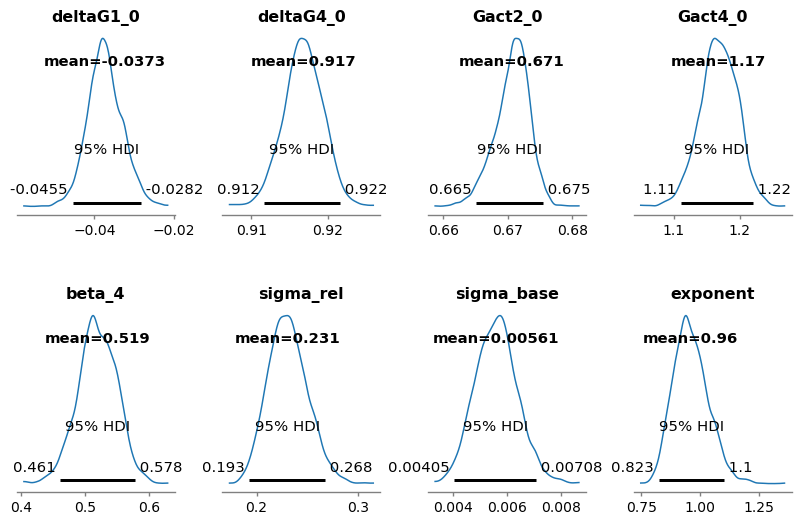

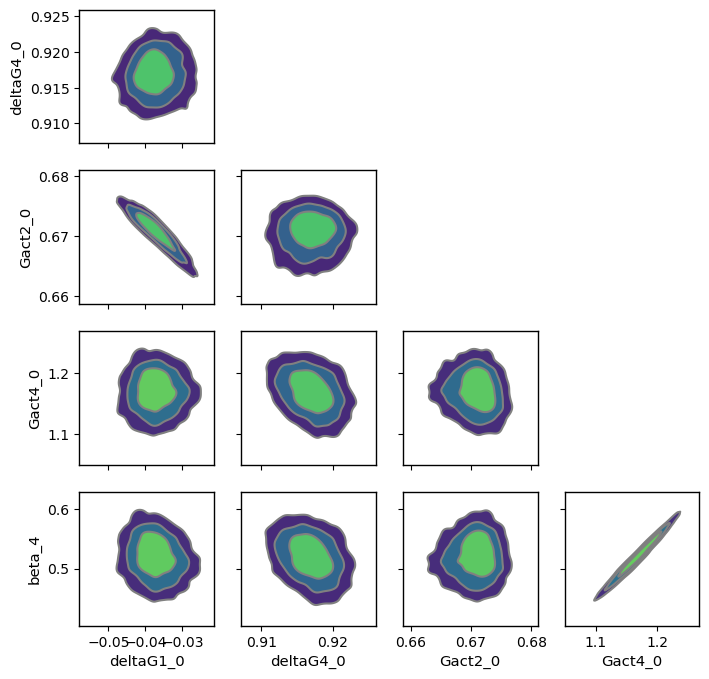

Sampling: [rate]


rate: 0.871


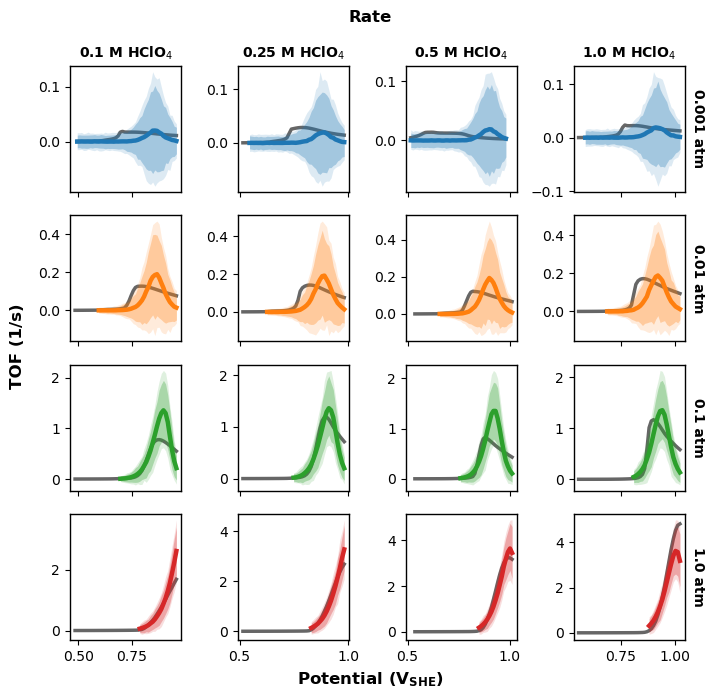

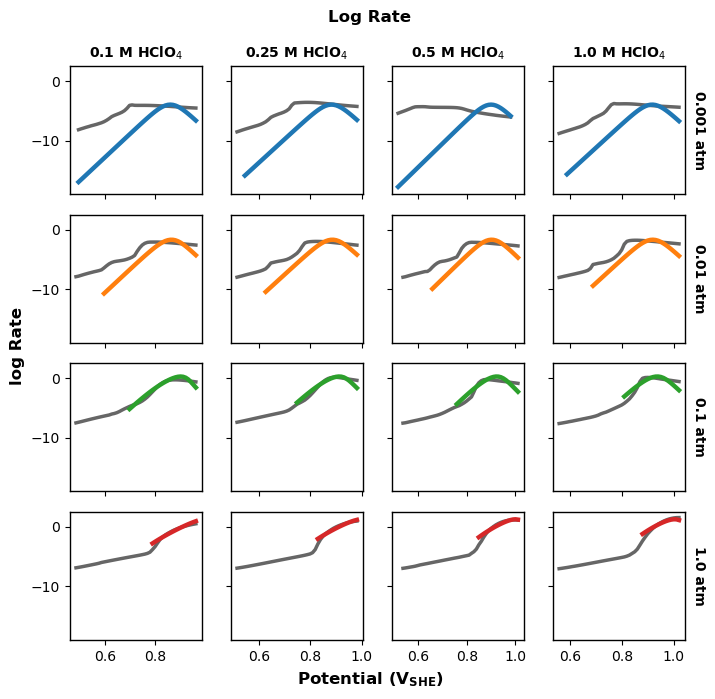

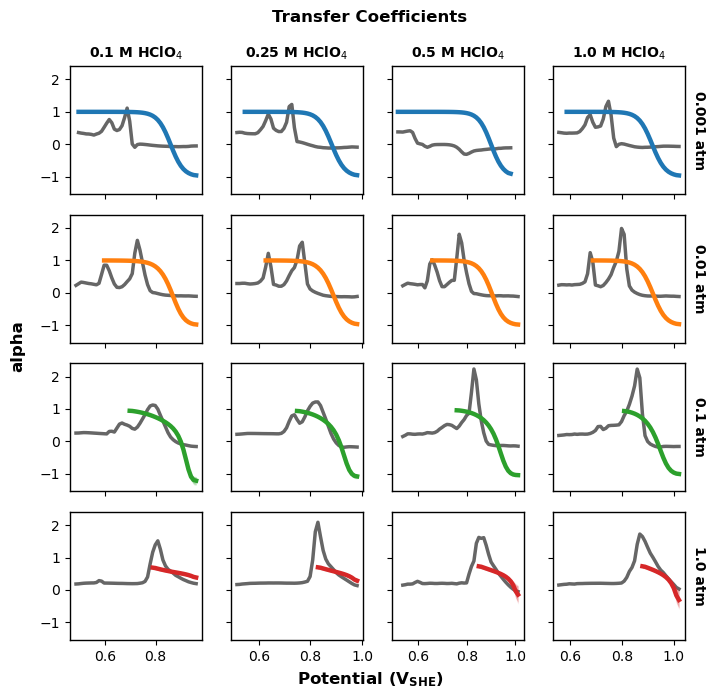

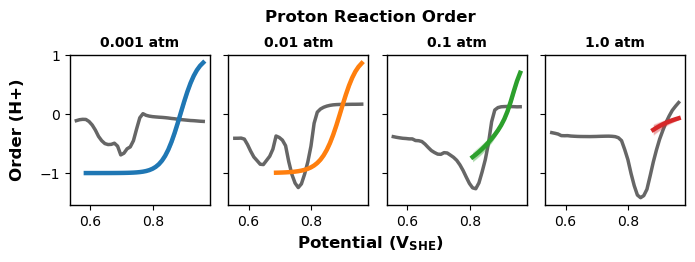

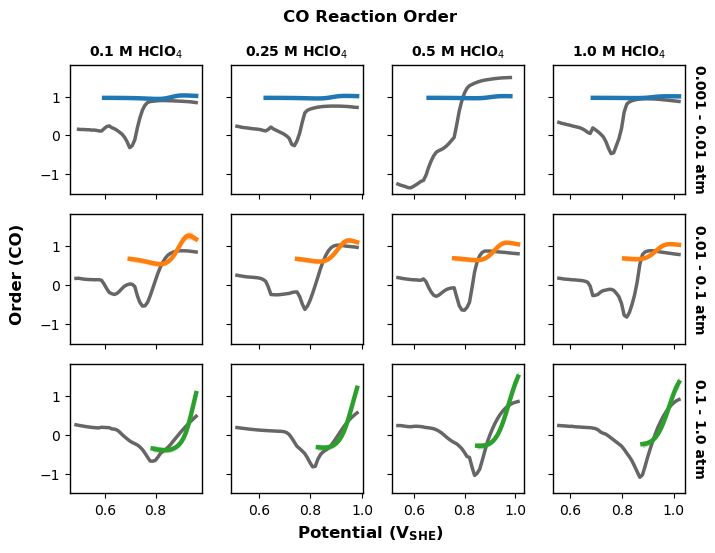

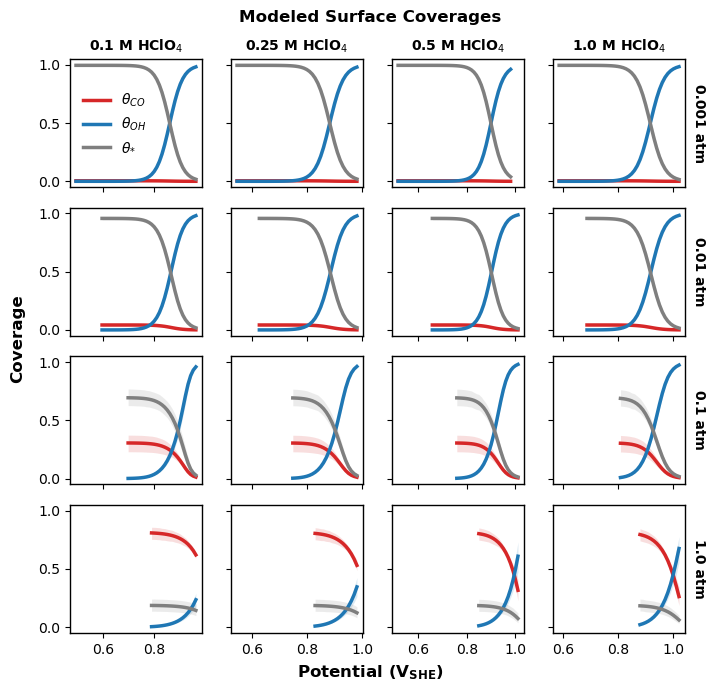

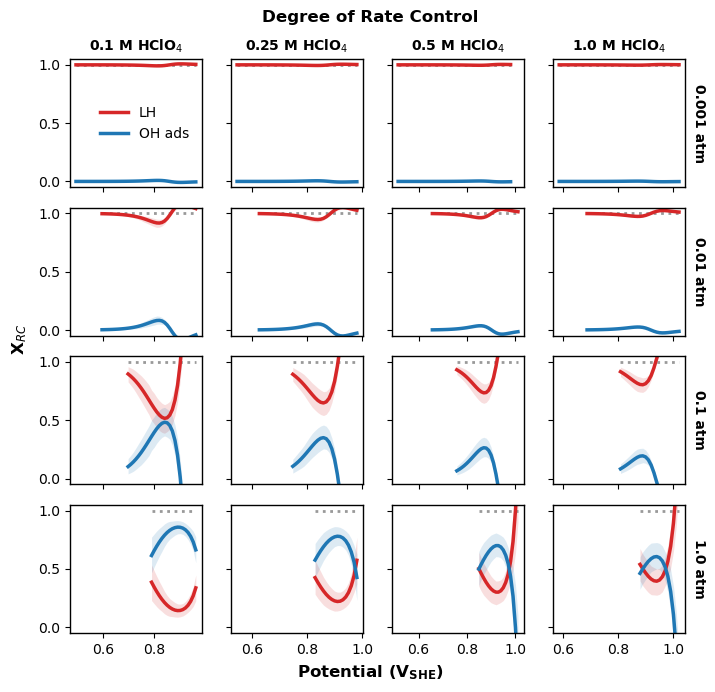

In [5]:
with pm.Model() as LH_2_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.8, sigma=0.05)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact4_0 = pm.Normal('Gact4_0', mu=1.2, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    Gact4 = Gact4_0 - beta_4*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k4 = np.log(kb_J*T/h) - Gact4/(kb_eV*T)
    log_k_minus4 = log_k4 - log_K4

    K1_Pco = pt.exp(log_K1 + np.log(P_CO_in))
    A = 1.0 + K1_Pco
    B = pt.exp(log_k_minus4 + np.log(C_H_in))
    C = pt.exp(log_k2) * K1_Pco
    k4_lin = pt.exp(log_k4)
    a_quad = A * C
    b_quad = (A * B) + k4_lin - C
    c_quad = -B
    theta_empty_lin = (-b_quad + pt.sqrt(b_quad**2 - 4 * a_quad * c_quad)) / (2 * a_quad)
    log_theta = pt.log(theta_empty_lin)
    log_theta_CO = log_K1 + np.log(P_CO_in) + log_theta
    log_denominator = pt.logsumexp(pt.stack([log_k_minus4 + np.log(C_H_in), log_k2 + log_theta_CO]), axis=0)
    log_theta_OH = log_k4 + log_theta - log_denominator

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', theta_empty_lin)

    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2_4, loo_LH_2_4 = fit_and_evaluate(LH_2_4)

ppc_LH_2_4 = plot_posteriors(trace_LH_2_4, LH_2_4)
plot_model_fits(trace_LH_2_4, ppc_LH_2_4); plot_coverages(trace_LH_2_4)
plot_drc(LH_2_4, trace_LH_2_4, perturb_vars=['Gact2_0', 'Gact4_0'], perturb_labels=['LH', 'OH ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact4_0': 'Gact'})

# LH PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.16,51
,3000,0,0.15,63
,3000,0,0.16,127
,3000,0,0.17,127


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   947.49    37.35
p_loo        8.17        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



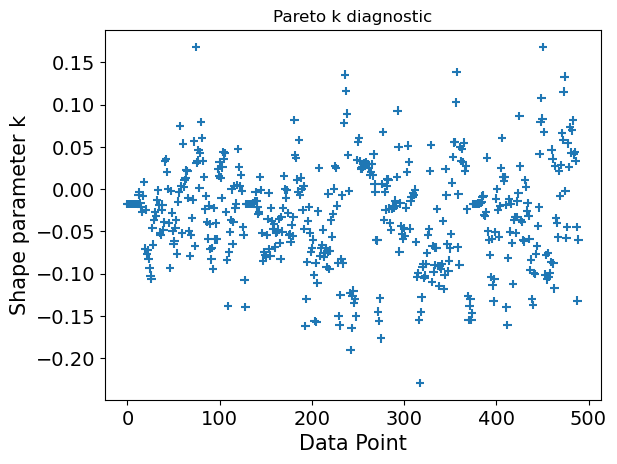

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.091  0.002  -0.096   -0.087      0.000    0.000    1835.0    2016.0    1.0
deltaG4_0   0.616  0.011   0.596    0.637      0.000    0.000     910.0    1261.0    1.0
Gact2_0     0.944  0.010   0.924    0.963      0.000    0.000     900.0    1242.0    1.0
beta_2      0.931  0.028   0.881    0.981      0.001    0.001    1193.0    1330.0    1.0
q           0.712  0.011   0.691    0.732      0.000    0.000     917.0    1242.0    1.0
sigma_rel   0.289  0.026   0.242    0.339      0.000    0.000    3158.0    2222.0    1.0
sigma_base  0.006  0.000   0.005    0.006      0.000    0.000    4477.0    2859.0    1.0
exponent    1.718  0.087   1.545    1.878      0.002    0.001    3164.0    2617.0    1.0


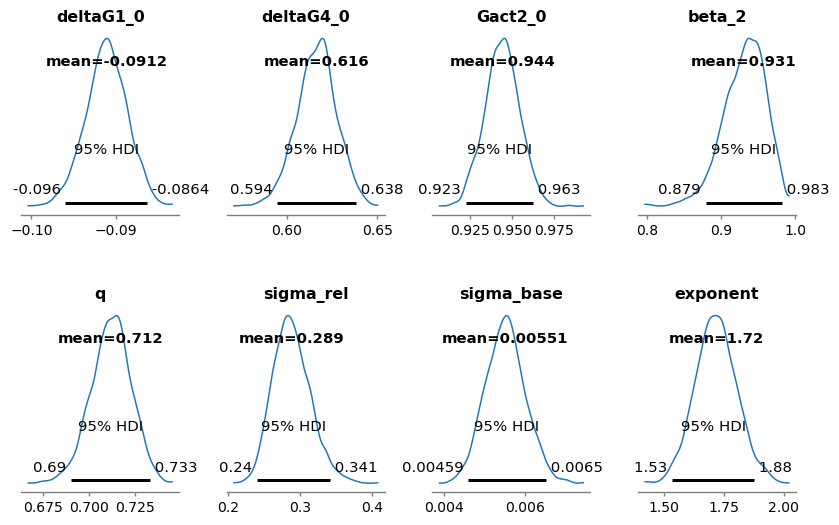

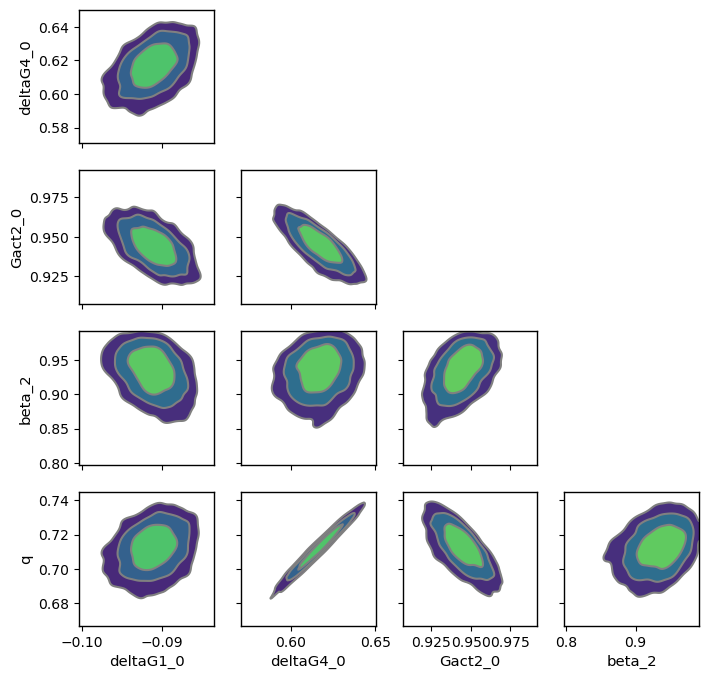

Sampling: [rate]


rate: 0.820


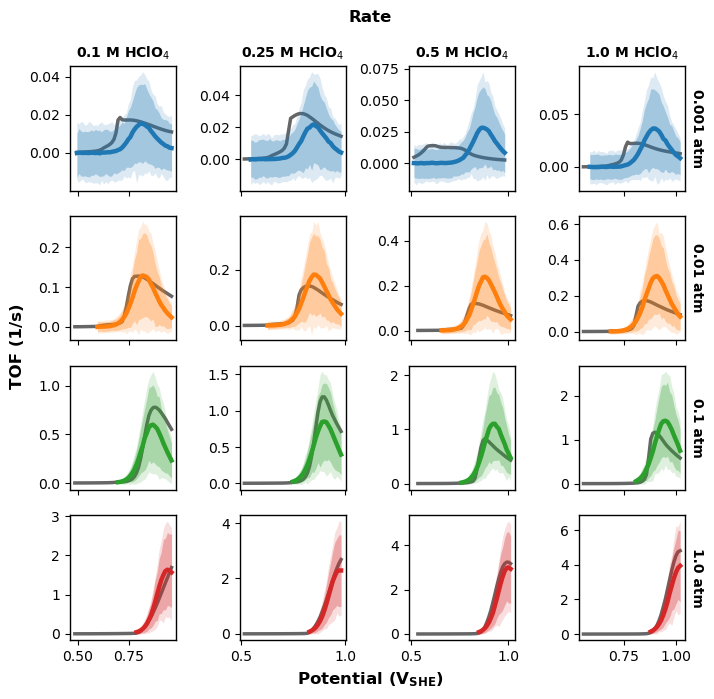

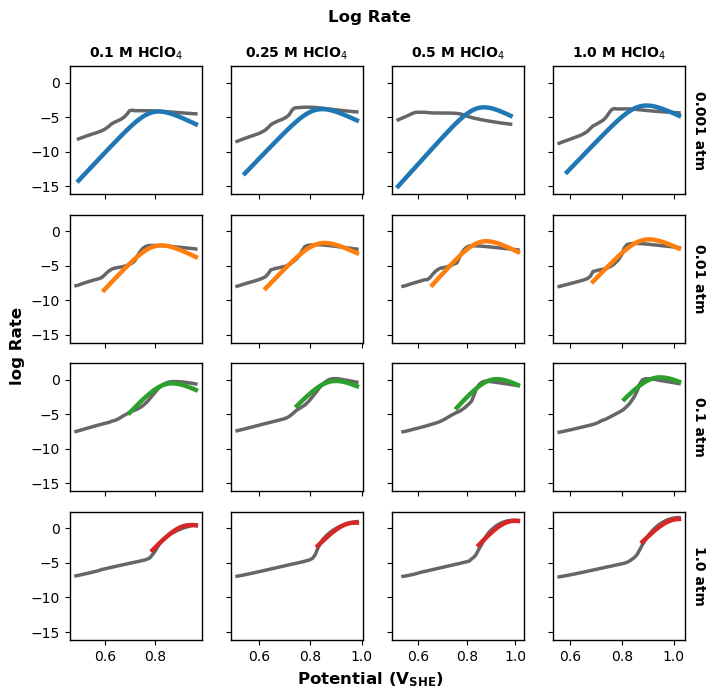

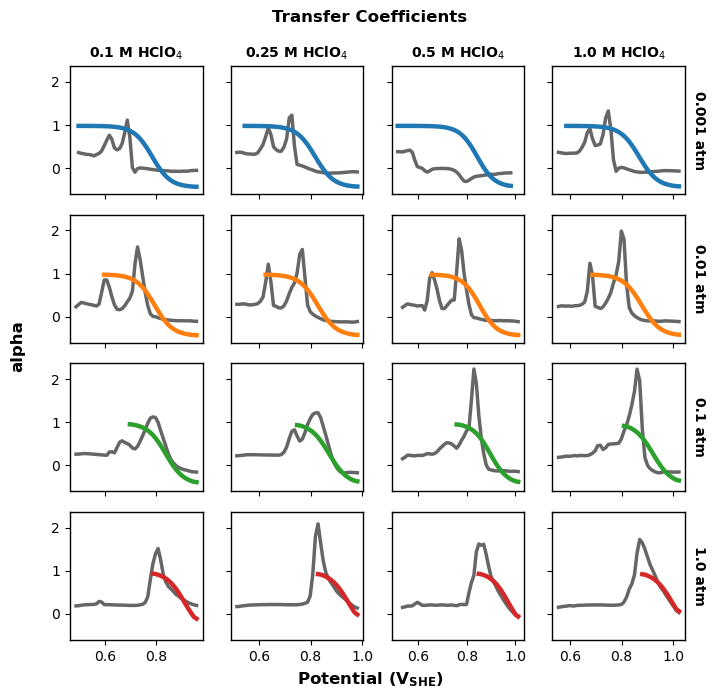

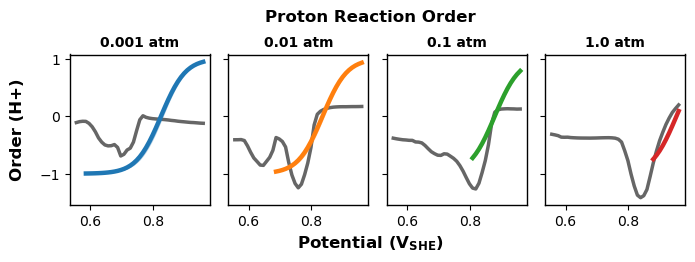

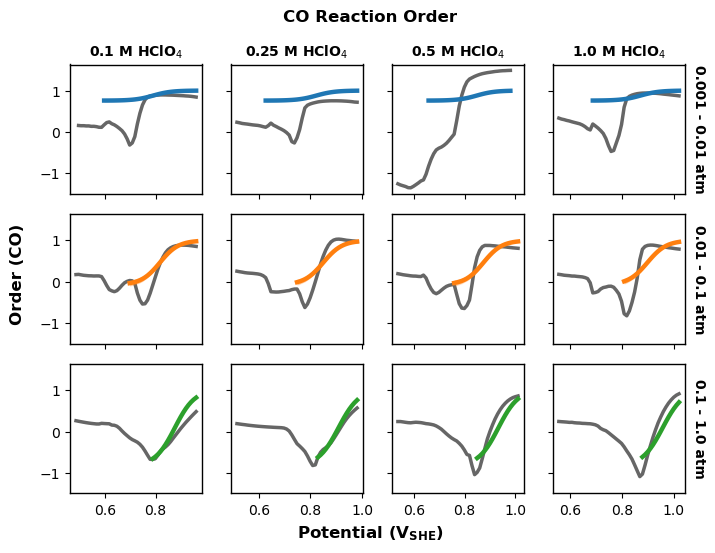

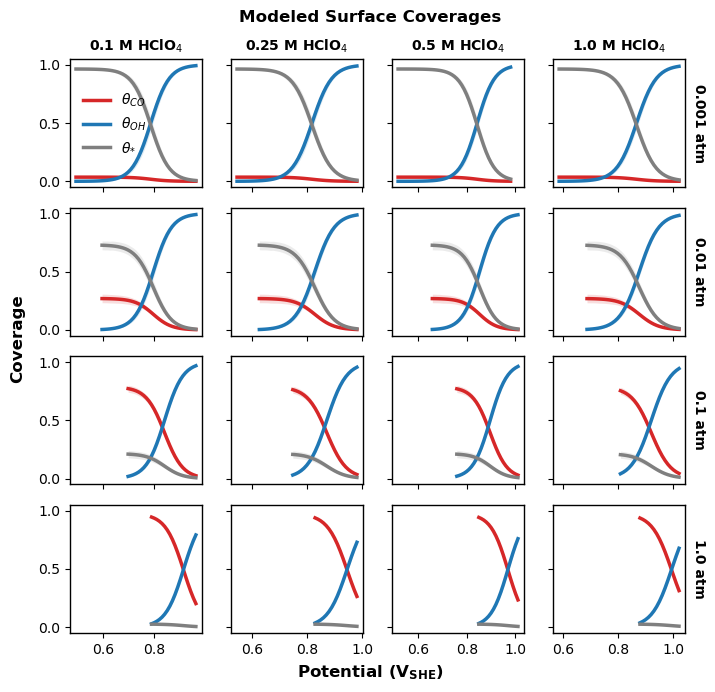

In [6]:
with pm.Model() as LH_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_PCT, loo_LH_PCT = fit_and_evaluate(LH_PCT)

ppc_LH_PCT = plot_posteriors(trace_LH_PCT, LH_PCT)
plot_model_fits(trace_LH_PCT, ppc_LH_PCT); plot_coverages(trace_LH_PCT)

# LH ER PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,255
,3000,0,0.11,31
,3000,0,0.13,223
,3000,0,0.12,127


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   954.32    37.36
p_loo       10.88        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



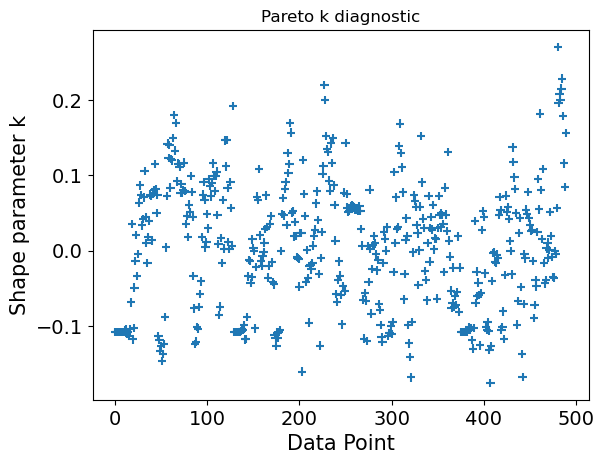

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.095  0.003  -0.101   -0.090      0.000    0.000    3117.0    2502.0   1.00
deltaG4_0   0.662  0.018   0.630    0.697      0.001    0.000    1241.0    1351.0   1.00
Gact2_LH_0  0.889  0.020   0.850    0.925      0.001    0.000    1176.0     912.0   1.00
Gact2_ER_0  1.434  0.040   1.360    1.506      0.001    0.002    1482.0    1463.0   1.01
beta_2_LH   0.831  0.070   0.705    0.953      0.002    0.002    1601.0    1820.0   1.00
beta_2_ER   0.729  0.046   0.655    0.807      0.001    0.005    1449.0    1580.0   1.01
q           0.760  0.019   0.726    0.796      0.001    0.000    1257.0    1361.0   1.00
sigma_rel   0.259  0.026   0.211    0.306      0.000    0.000    3614.0    3008.0   1.00
sigma_base  0.005  0.000   0.004    0.006      0.000    0.000    4515.0    2942.0   1.00
exponent    1.627  0.093   1.449    1.794      0.002    0.002    3522.0    3109.0   1.00


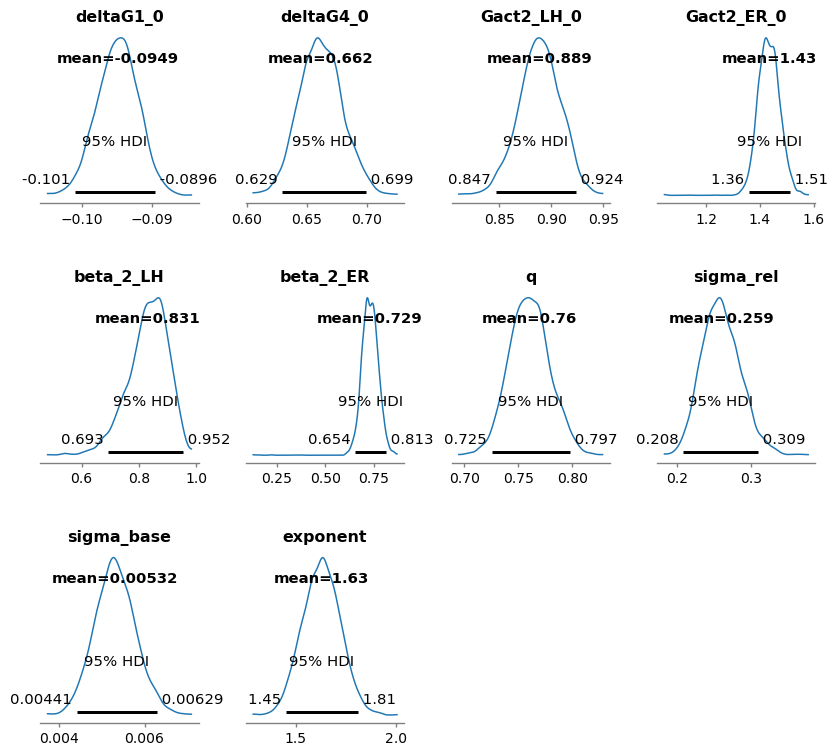

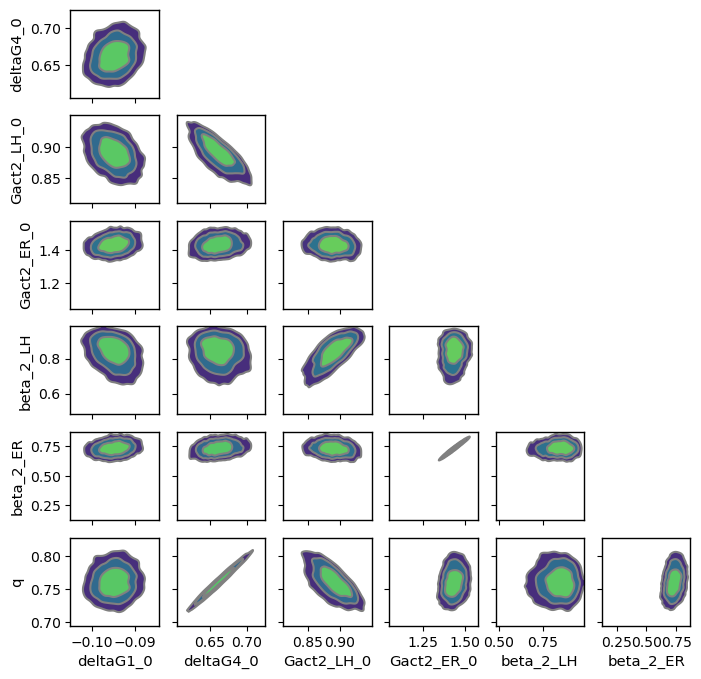

Sampling: [rate]


rate: 0.873


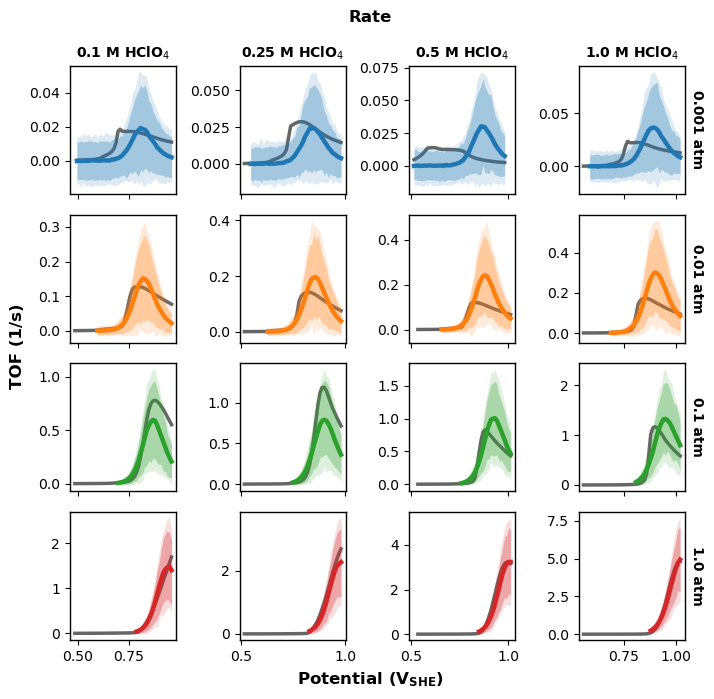

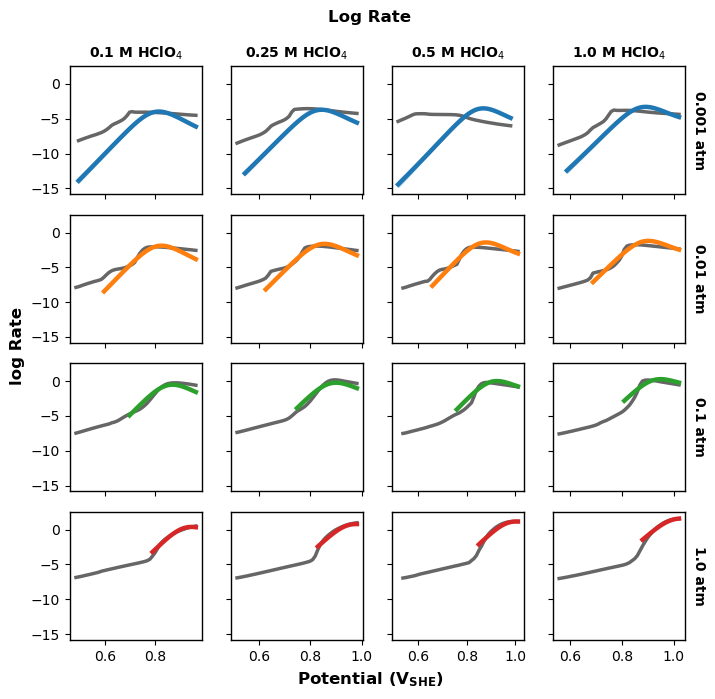

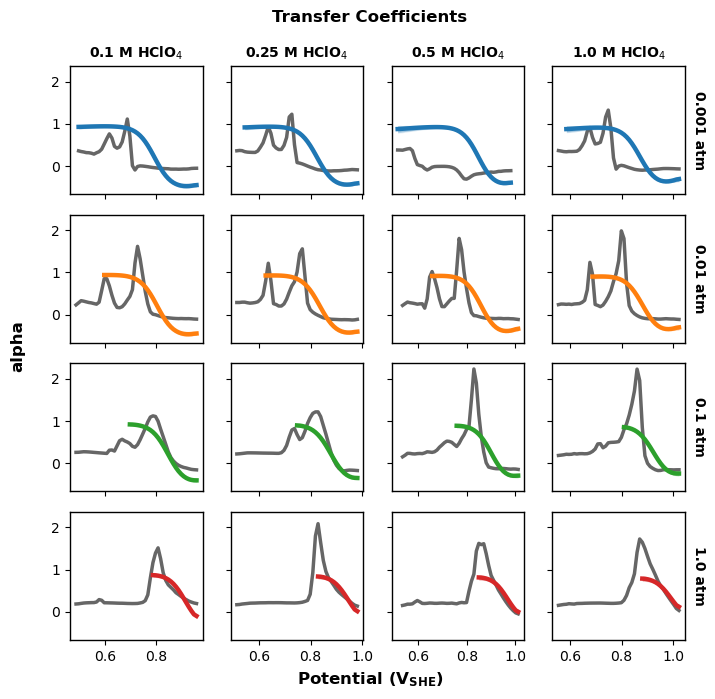

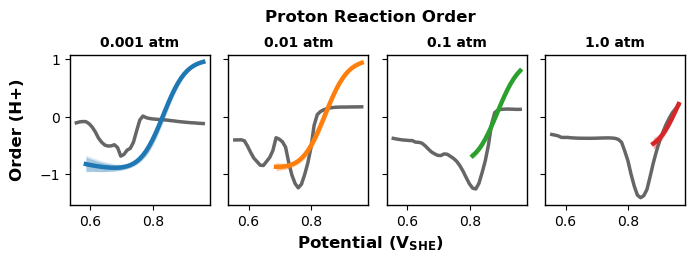

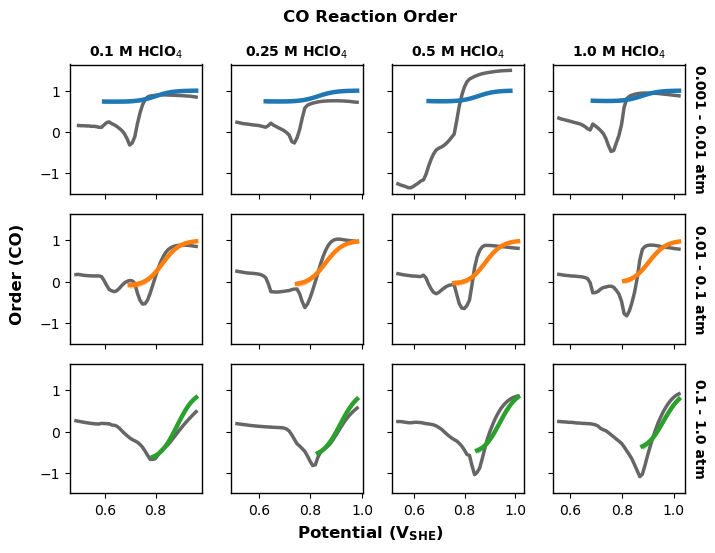

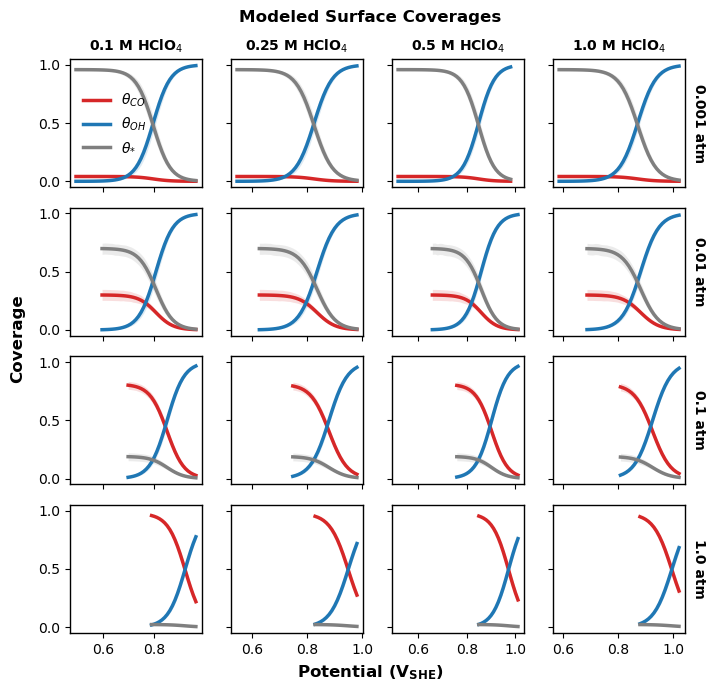

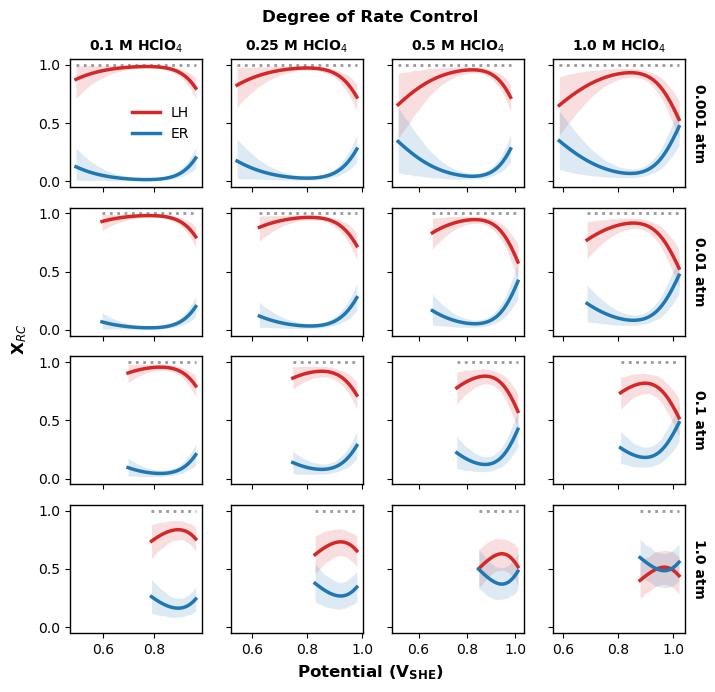

In [7]:
with pm.Model() as LH_ER_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    2b. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2_LH = Gact2_LH_0 - beta_2_LH*(1-q)*E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_ER = log_k2_ER + log_theta_CO 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate) 

trace_LH_ER_PCT, loo_LH_ER_PCT = fit_and_evaluate(LH_ER_PCT)

ppc_LH_ER_PCT = plot_posteriors(trace_LH_ER_PCT, LH_ER_PCT)
plot_model_fits(trace_LH_ER_PCT, ppc_LH_ER_PCT); plot_coverages(trace_LH_ER_PCT)
plot_drc(LH_ER_PCT, trace_LH_ER_PCT, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['LH', 'ER'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact'})

# LH PCT 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,1,0.13,127
,3000,0,0.14,127
,3000,0,0.12,31


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   947.30    37.34
p_loo        8.27        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



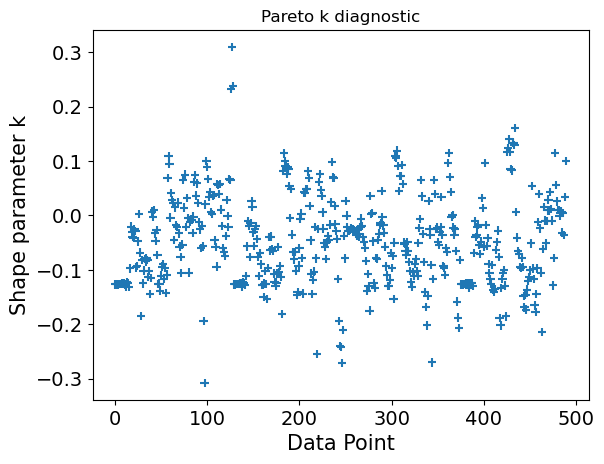

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.091  0.002  -0.095   -0.087      0.000    0.000    1906.0    2258.0   1.00
deltaG4_0   0.617  0.011   0.596    0.636      0.000    0.000     752.0    1093.0   1.01
Gact2_0     0.943  0.010   0.925    0.962      0.000    0.000     785.0     959.0   1.01
Gact4_0     0.812  0.142   0.536    1.071      0.003    0.002    2249.0    2088.0   1.00
beta_2      0.930  0.029   0.879    0.980      0.001    0.001    1164.0    1486.0   1.00
q           0.713  0.010   0.693    0.732      0.000    0.000     774.0    1121.0   1.01
beta_4      0.585  0.142   0.318    0.838      0.003    0.002    3024.0    1766.0   1.00
sigma_rel   0.289  0.026   0.241    0.338      0.000    0.000    3078.0    2910.0   1.00
sigma_base  0.006  0.000   0.005    0.006      0.000    0.000    4270.0    3143.0   1.00
exponent    1.718  0.085   1.567    1.884      0.002    0.001    2985.0    2573.0   1.00


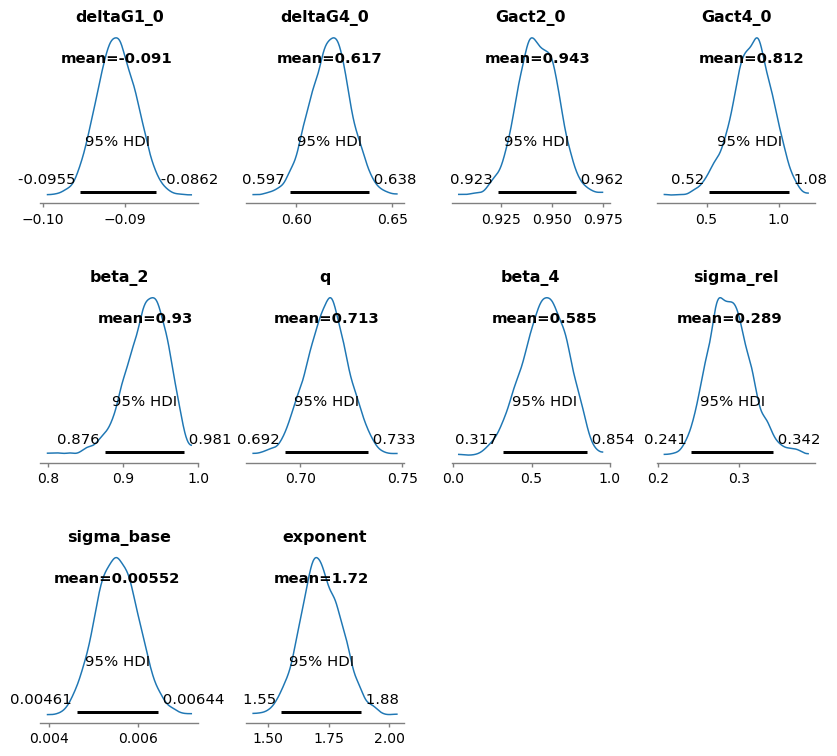

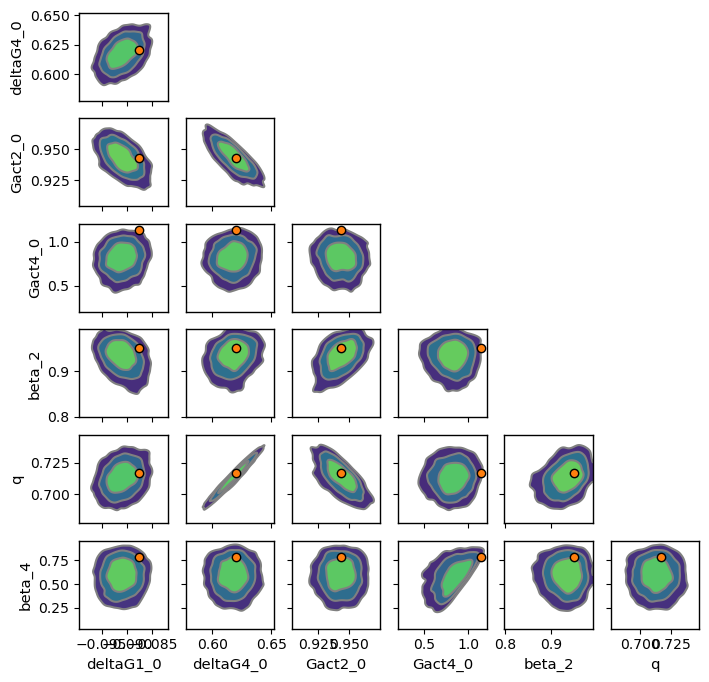

Sampling: [rate]


rate: 0.821


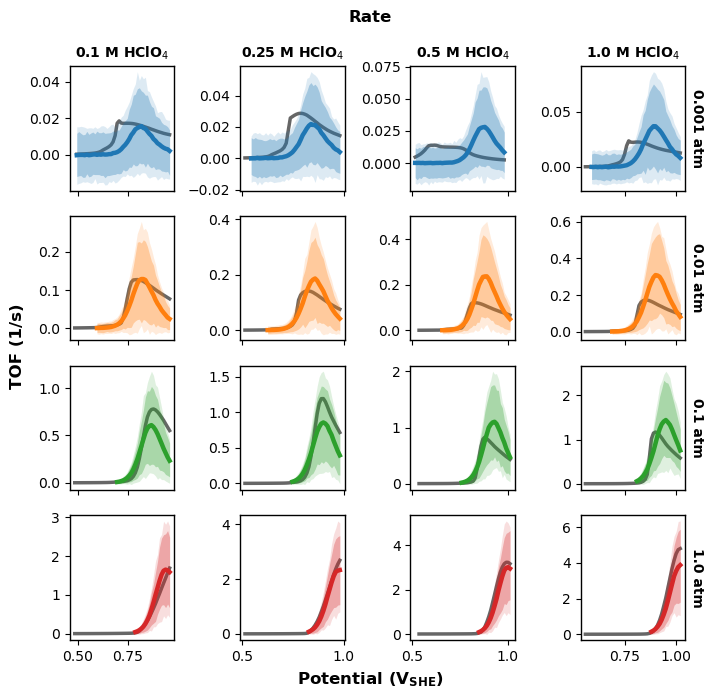

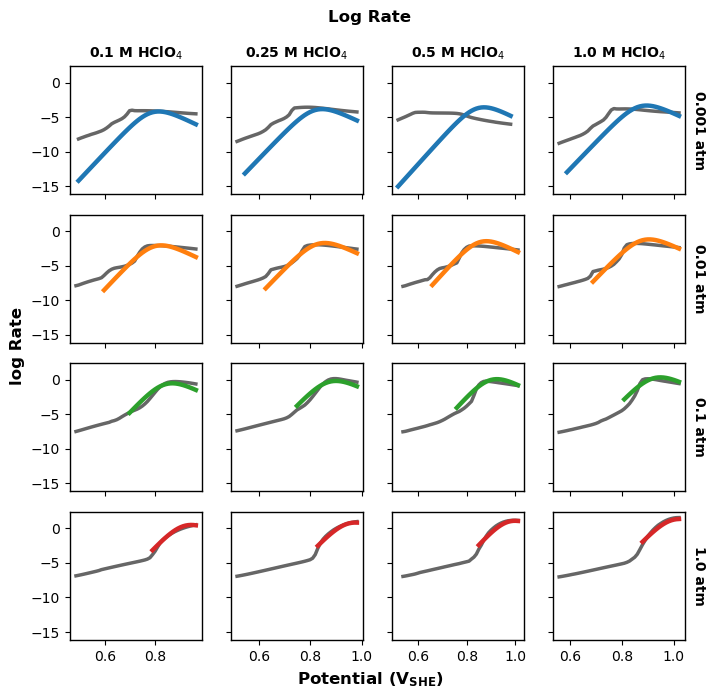

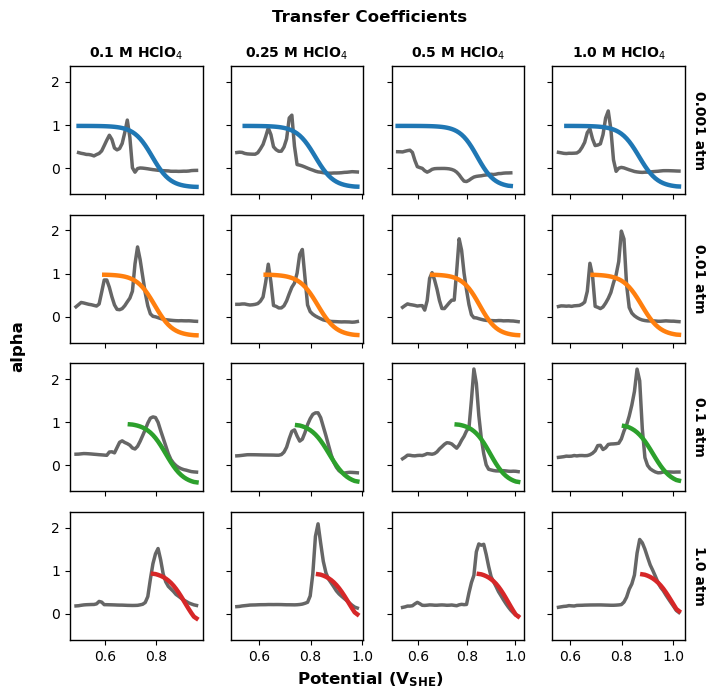

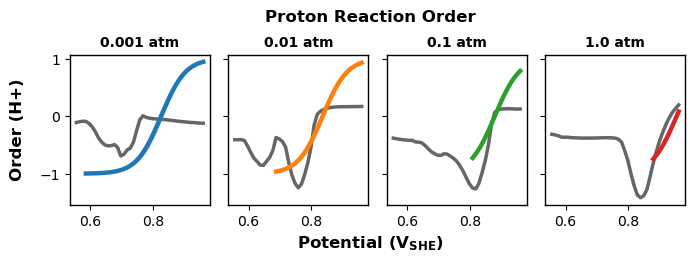

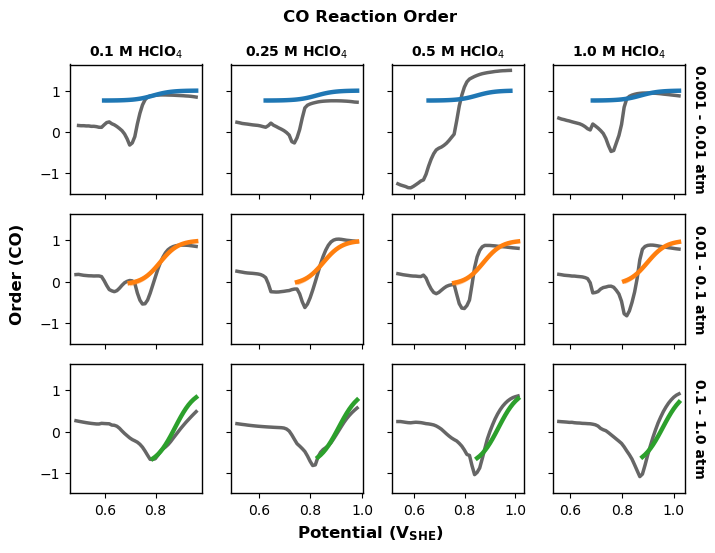

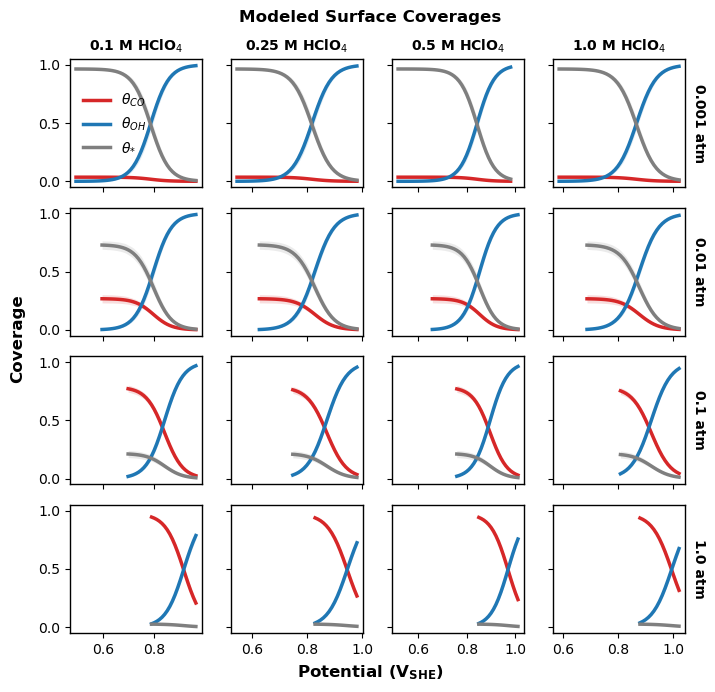

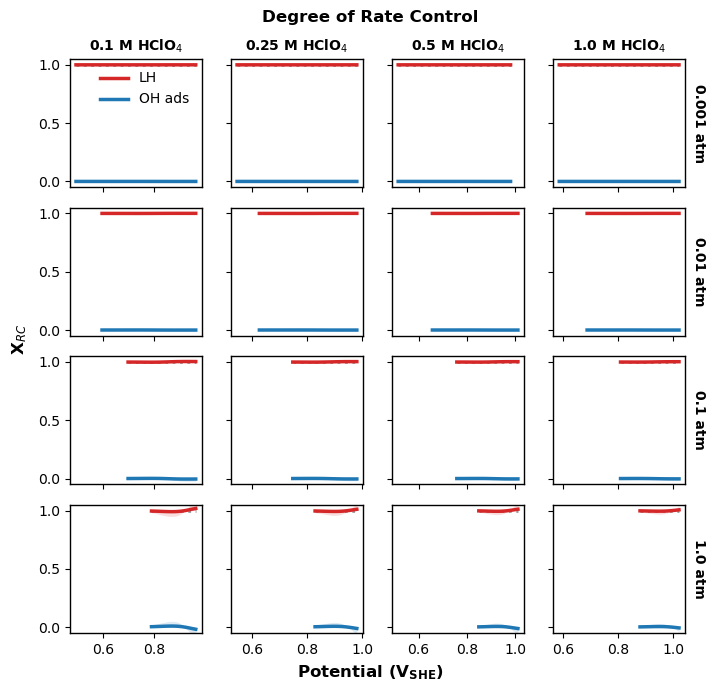

In [11]:
with pm.Model() as LH_PCT_4:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact4_0 = pm.Normal('Gact4_0', mu=1.0, sigma=0.2)

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    Gact4 = Gact4_0 - beta_4*q*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k4f = np.log(kb_J*T/h) - Gact4/(kb_eV*T)
    log_k4b = log_k4f - log_K4

    K1_PCO = pt.exp(log_K1) * P_CO_in
    k2 = pt.exp(log_k2)
    k4f = pt.exp(log_k4f)
    k4b = pt.exp(log_k4b)
    A = 1.0 + K1_PCO
    B = k4b * C_H_in
    C_coeff = k2 * K1_PCO
    a = A * C_coeff
    b = A * B + k4f - C_coeff
    c = -B
    
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_CO = pm.Deterministic('theta_CO', K1_PCO * theta_empty)
    theta_OH = pm.Deterministic('theta_OH', (k4f * theta_empty) / (B + C_coeff * theta_empty))

    # Rate expression
    log_rate = log_k2 + pt.log(theta_CO) + pt.log(theta_OH)
    rate = observables(log_rate) 

trace_LH_PCT_4, loo_LH_PCT_4 = fit_and_evaluate(LH_PCT_4)

ppc_LH_PCT_4 = plot_posteriors(trace_LH_PCT_4, LH_PCT_4)
plot_model_fits(trace_LH_PCT_4, ppc_LH_PCT_4); plot_coverages(trace_LH_PCT_4)
plot_drc(LH_PCT_4, trace_LH_PCT_4, perturb_vars=['Gact2_0', 'Gact4_0'], perturb_labels=['LH', 'OH ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact4_0': 'Gact'})

# LH PCT 1

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.14,127
,3000,0,0.15,31
,3000,0,0.15,63
,3000,0,0.16,63


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   951.43    37.33
p_loo        9.28        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



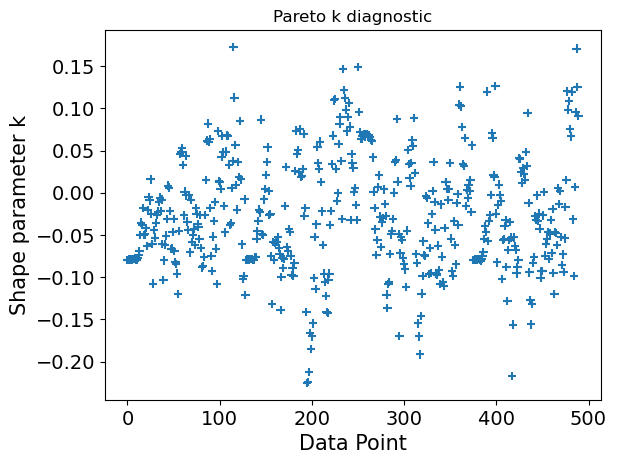

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.093  0.003  -0.098   -0.088      0.000    0.000    1422.0    1933.0   1.00
deltaG4_0   0.580  0.017   0.550    0.612      0.001    0.000     602.0     725.0   1.01
Gact1_0     0.580  0.015   0.559    0.600      0.001    0.002     763.0    1023.0   1.00
Gact2_0     0.972  0.014   0.943    0.996      0.001    0.000     698.0    1006.0   1.01
beta_2      0.910  0.036   0.845    0.973      0.001    0.001    1002.0    1380.0   1.00
q           0.669  0.019   0.634    0.703      0.001    0.001     591.0     662.0   1.01
sigma_rel   0.268  0.024   0.225    0.313      0.000    0.000    3292.0    2988.0   1.00
sigma_base  0.005  0.001   0.004    0.006      0.000    0.000    4403.0    2799.0   1.00
exponent    1.635  0.083   1.477    1.788      0.002    0.001    3040.0    2652.0   1.00


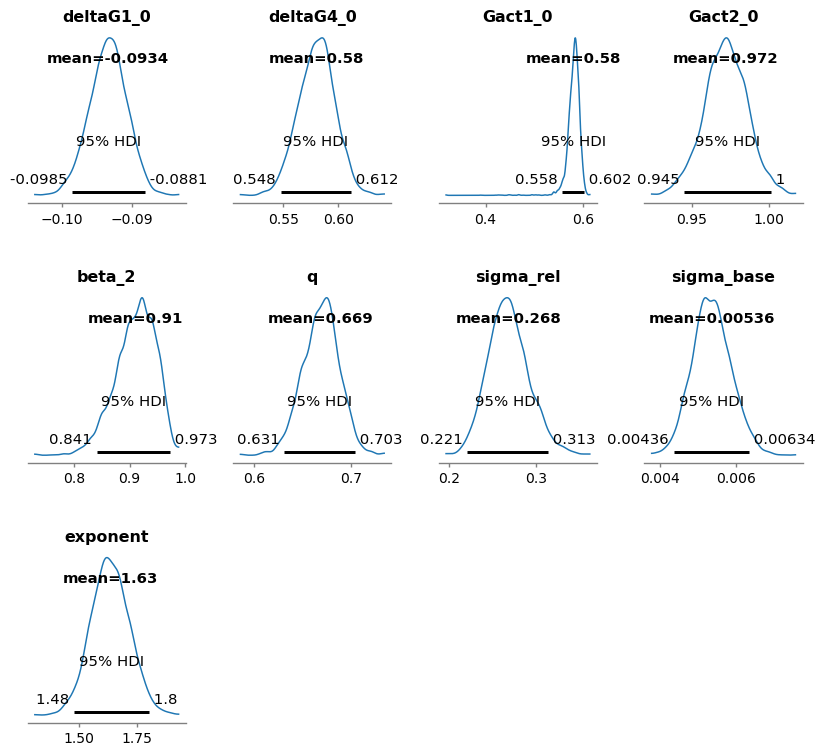

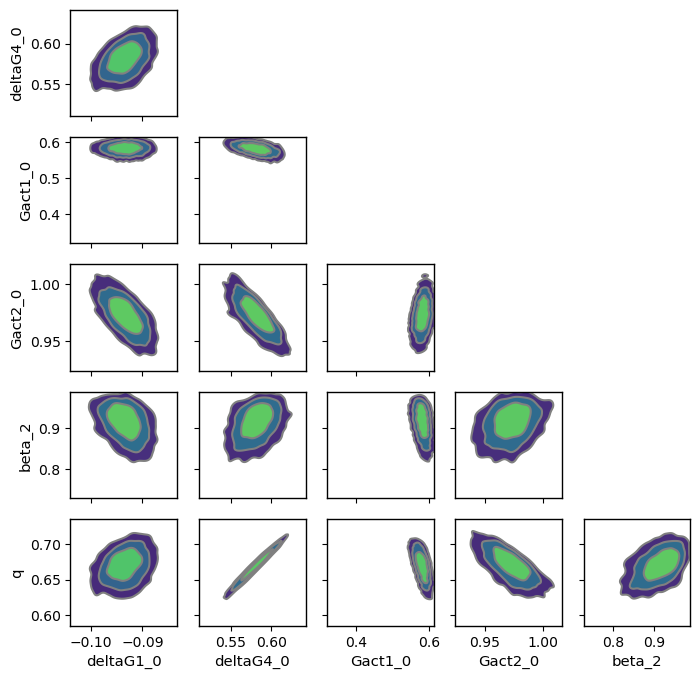

Sampling: [rate]


rate: 0.861


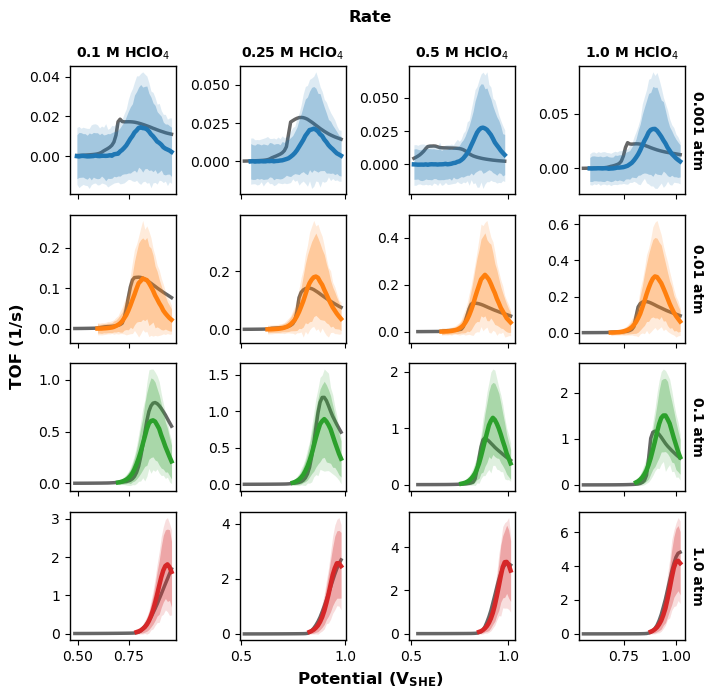

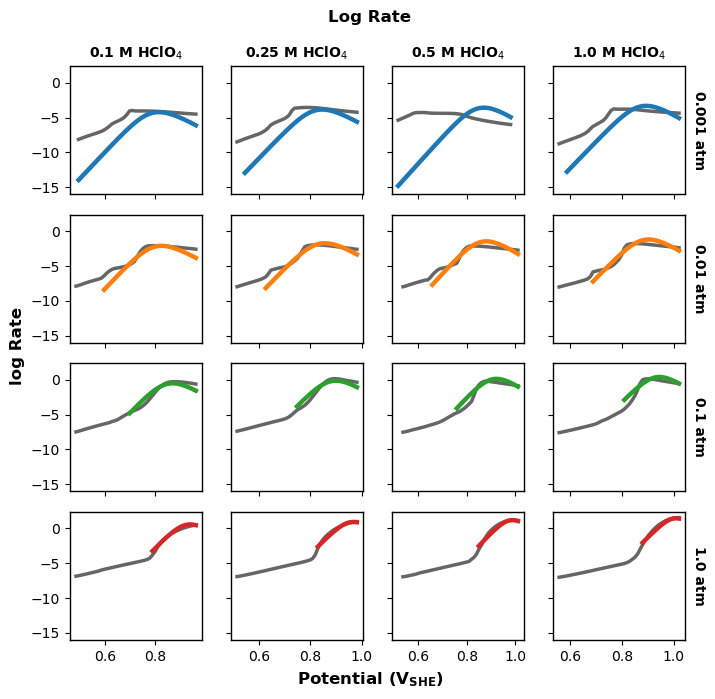

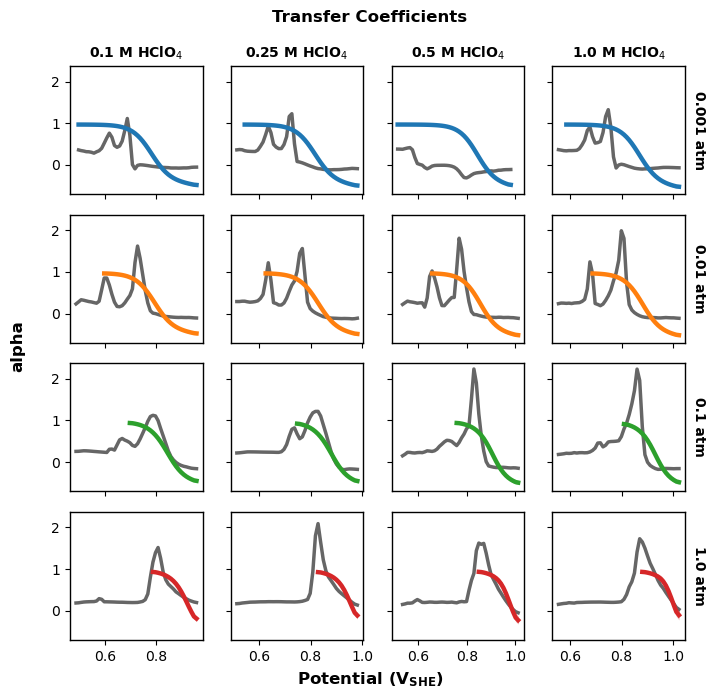

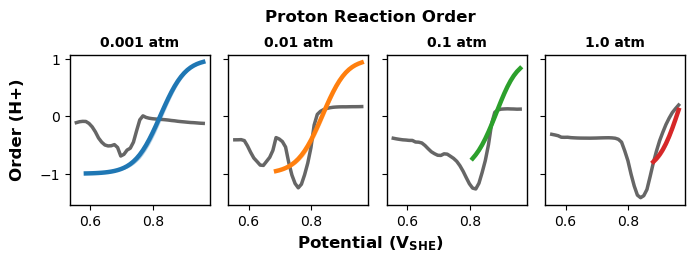

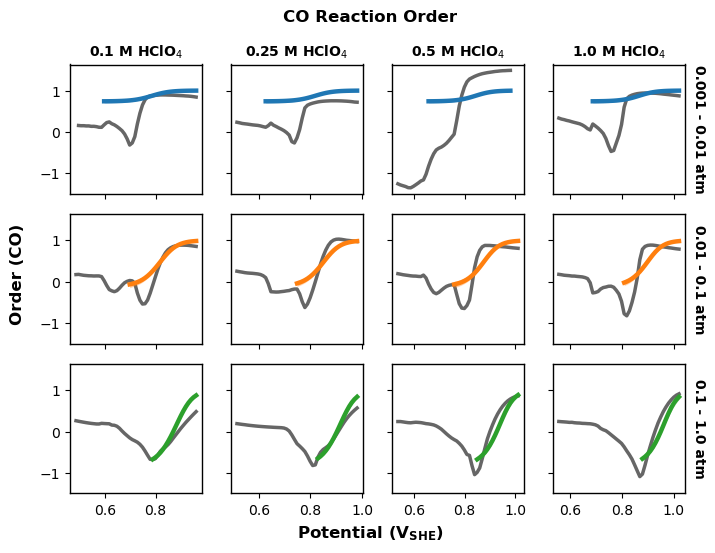

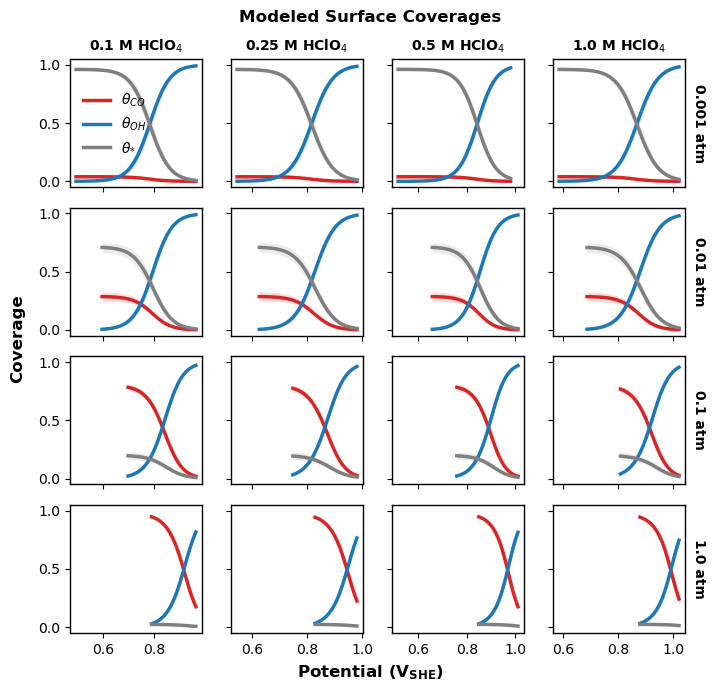

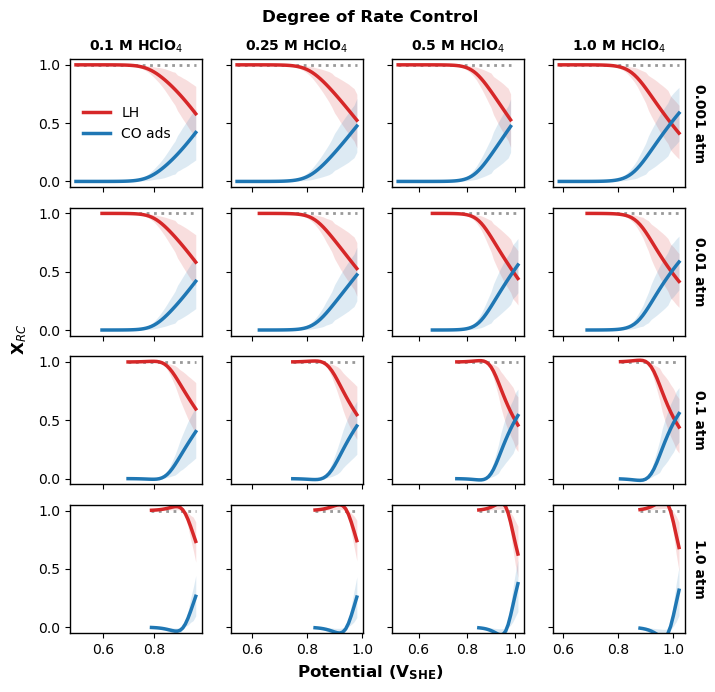

In [19]:
with pm.Model() as LH_PCT_1:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2) 
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact1 = Gact1_0 
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1f = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    
    log_k1b = log_k1f - log_K1
    K4_prime = pt.exp(log_K4) / C_H_in
    k1f_PCO = pt.exp(log_k1f) * P_CO_in
    k1b = pt.exp(log_k1b)
    k2 = pt.exp(log_k2)
    A = 1.0 + K4_prime
    a = A * k2 * K4_prime
    b = A * k1b + k1f_PCO - k2 * K4_prime
    c = -k1b
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_OH = pm.Deterministic('theta_OH', K4_prime * theta_empty)
    theta_CO = pm.Deterministic('theta_CO', (k1f_PCO * theta_empty) / (k1b + k2 * theta_OH))

    # Rate expression
    log_rate = log_k2 + pt.log(theta_CO) + pt.log(theta_OH)
    rate = observables(log_rate) 

trace_LH_PCT_1, loo_LH_PCT_1 = fit_and_evaluate(LH_PCT_1)

ppc_LH_PCT_1 = plot_posteriors(trace_LH_PCT_1, LH_PCT_1)
plot_model_fits(trace_LH_PCT_1, ppc_LH_PCT_1); plot_coverages(trace_LH_PCT_1)
plot_drc(LH_PCT_1, trace_LH_PCT_1, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['LH', 'CO ads'], 
         var_types={'Gact2_0': 'Gact', 'Gact1_0': 'Gact'})

# LH ER PCT 1

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.11,127
,3000,0,0.14,95
,3000,0,0.12,63
,3000,0,0.11,255


Computed from 4000 posterior samples and 490 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1090.33    42.21
p_loo       13.40        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      490  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



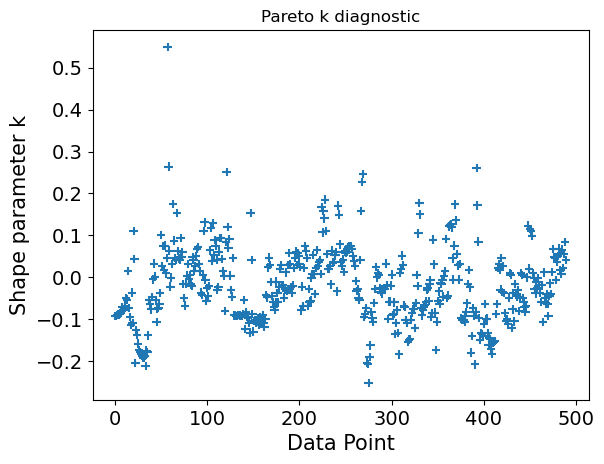

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.448  0.163  -0.733   -0.197      0.003    0.002    2595.0    2257.0   1.00
deltaG4_0   0.564  0.029   0.509    0.615      0.001    0.001     629.0     851.0   1.01
Gact2_LH_0  0.757  0.029   0.705    0.809      0.001    0.001     615.0     730.0   1.01
Gact2_ER_0  1.304  0.014   1.279    1.330      0.000    0.000    1210.0    1406.0   1.00
Gact1_0     0.671  0.001   0.669    0.673      0.000    0.000    3149.0    2545.0   1.00
beta_2_LH   0.201  0.060   0.087    0.307      0.002    0.001     684.0    1080.0   1.00
beta_2_ER   0.606  0.016   0.577    0.637      0.000    0.000    1190.0    1318.0   1.00
q           0.563  0.030   0.507    0.616      0.001    0.001     632.0     820.0   1.01
sigma_rel   0.264  0.021   0.226    0.303      0.000    0.000    3657.0    2913.0   1.00
sigma_base  0.003  0.000   0.002    0.004      0.000    0.000    4288.0    3041.0   1.00
exponent    1.850  0.

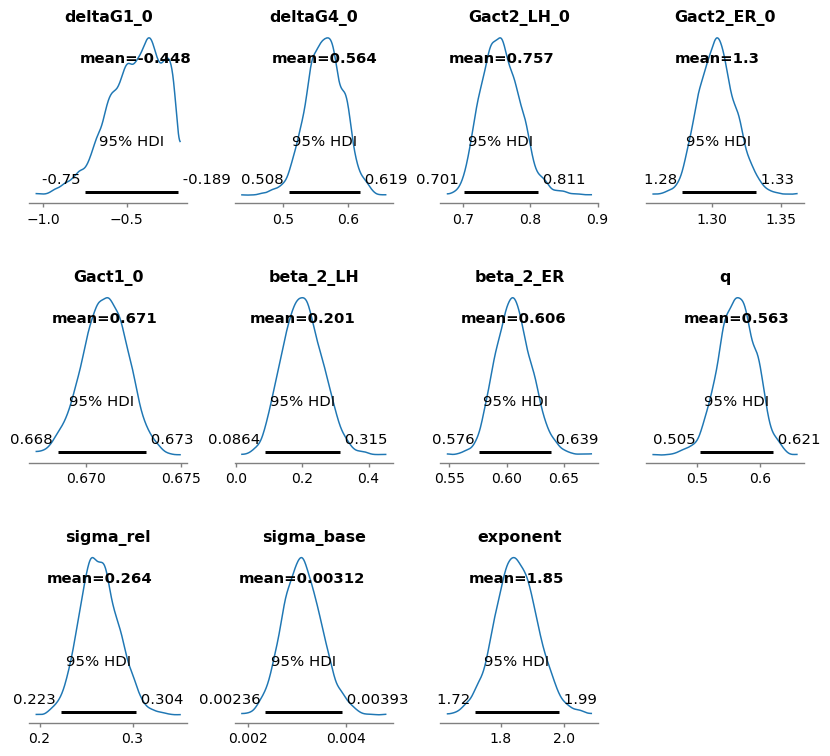

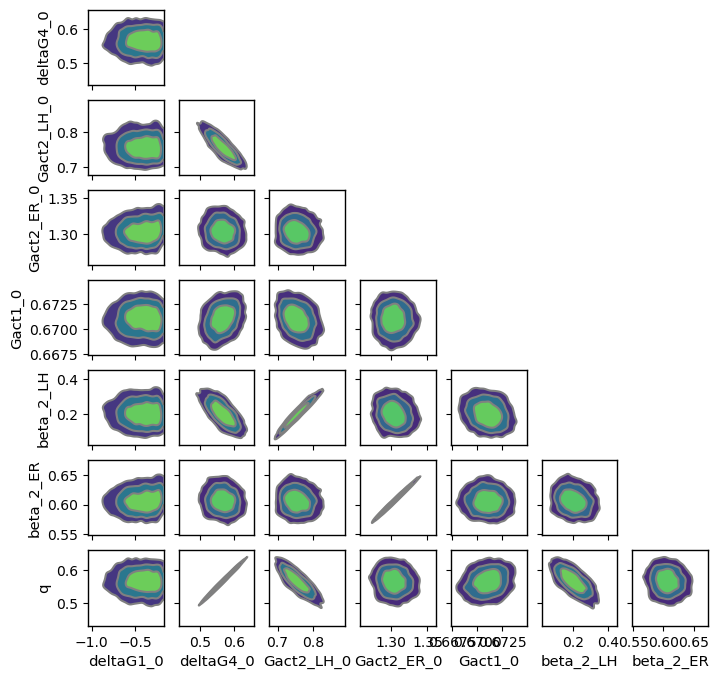

Sampling: [rate]


rate: 0.834


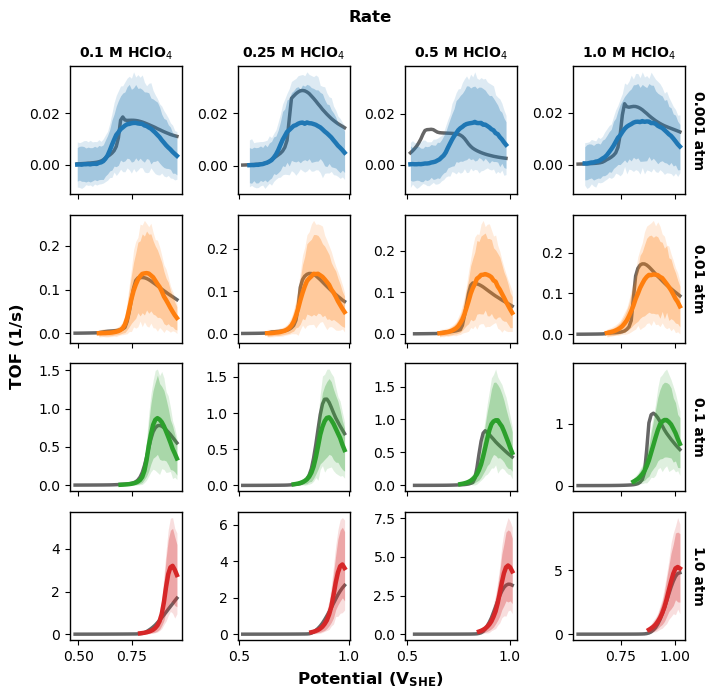

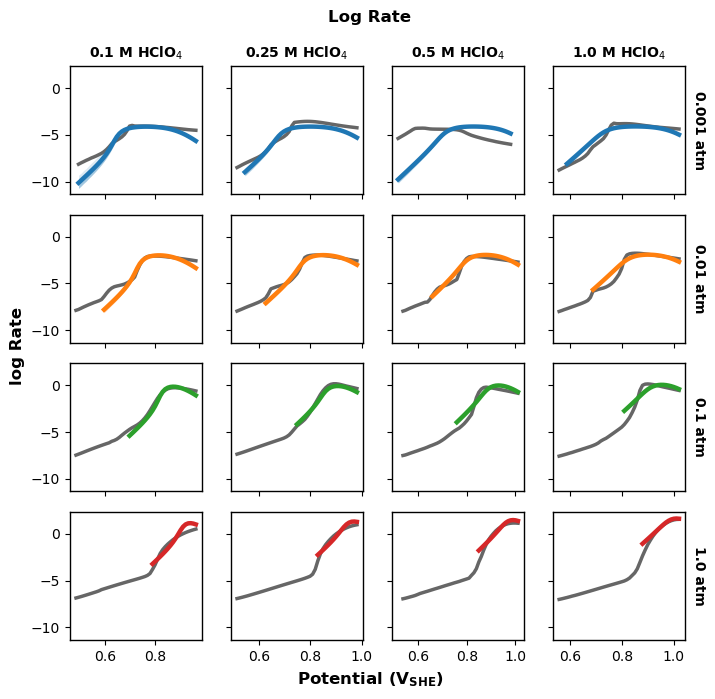

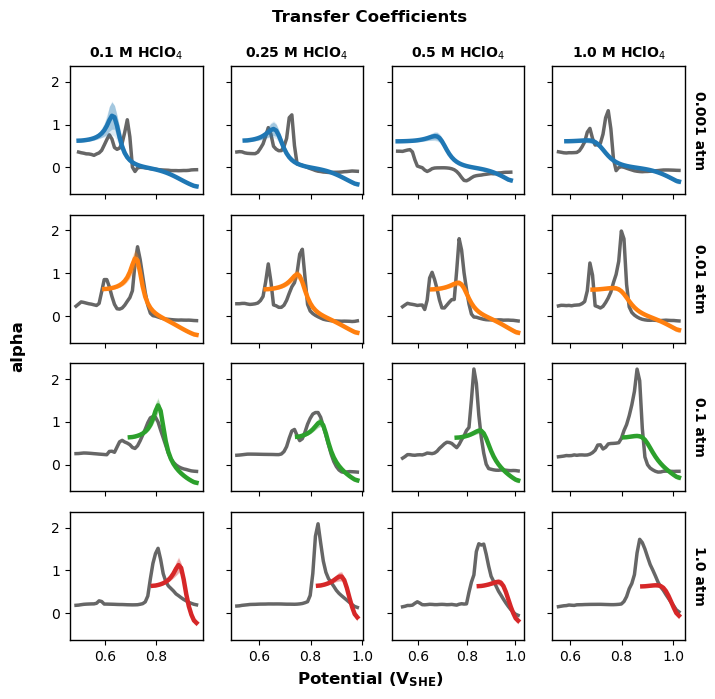

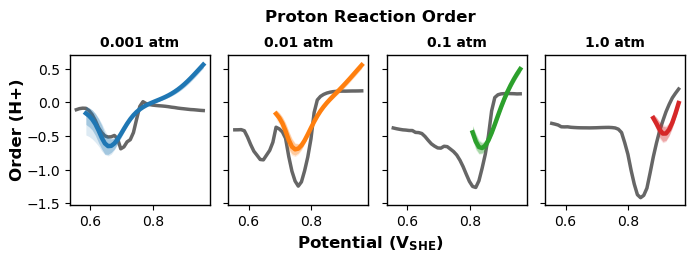

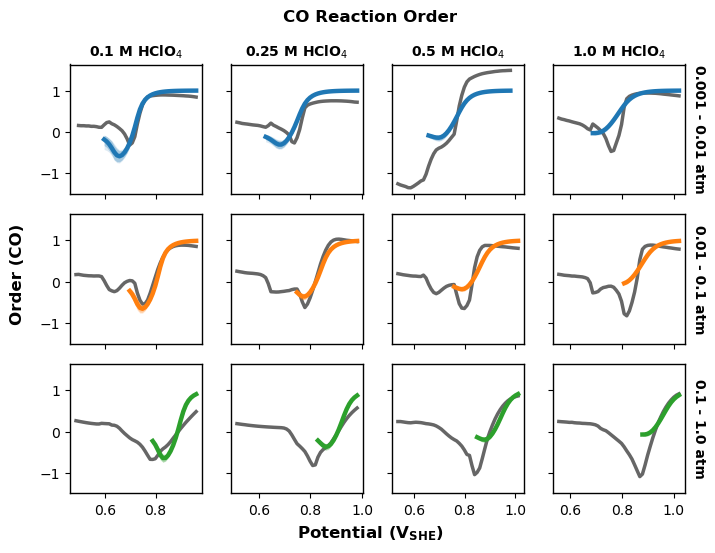

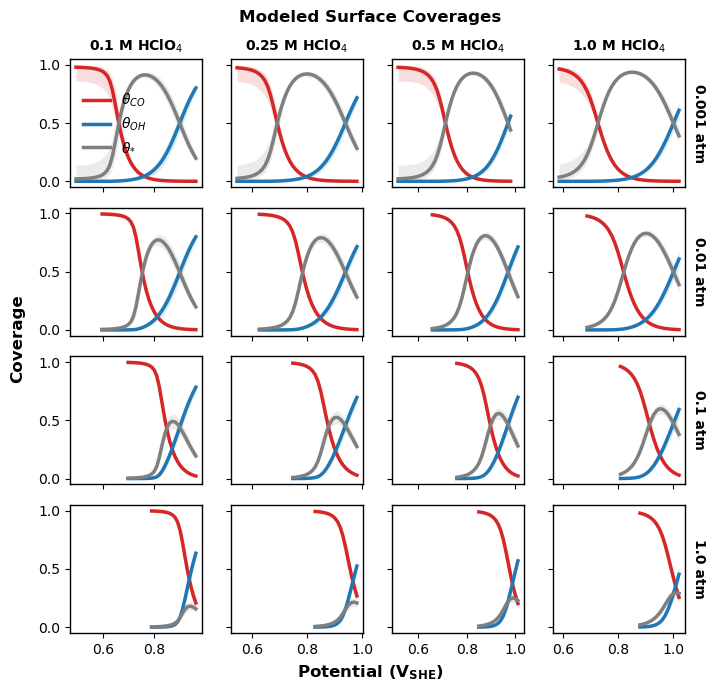

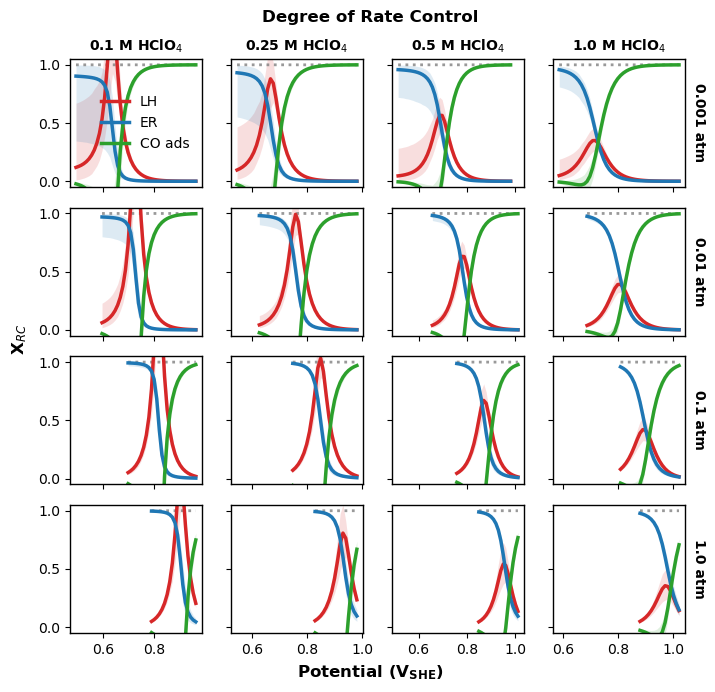

In [20]:
with pm.Model() as LH_ER_PCT_1:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (SSA)
    2b. CO* + H2O -> COOH* + H+ + (e-) (SSA)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2_LH = Gact2_LH_0 - beta_2_LH*(1-q)*E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER*E_in
    Gact1 = Gact1_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1f = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k1b = log_k1f - log_K1

    K4_prime = pt.exp(log_K4) / C_H_in
    k1f_PCO = pt.exp(log_k1f) * P_CO_in
    k1b = pt.exp(log_k1b)
    k2_LH = pt.exp(log_k2_LH)
    k2_ER = pt.exp(log_k2_ER)
    A = 1.0 + K4_prime
    a = A * k2_LH * K4_prime
    b = A * (k1b + k2_ER) + k1f_PCO - k2_LH * K4_prime
    c = -(k1b + k2_ER)
    
    theta_empty = pm.Deterministic('theta_empty', (2.0 * (-c)) / (b + pt.sqrt(b**2 - 4.0 * a * c)))
    theta_OH = pm.Deterministic('theta_OH', K4_prime * theta_empty)
    theta_CO = pm.Deterministic('theta_CO', (k1f_PCO * theta_empty) / (k1b + k2_ER + k2_LH * theta_OH))

    # Rate expression
    log_rate_LH = log_k2_LH + pt.log(theta_CO) + pt.log(theta_OH)
    log_rate_ER = log_k2_ER + pt.log(theta_CO) 
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate)

trace_LH_ER_PCT_1, loo_LH_ER_PCT_1 = fit_and_evaluate(LH_ER_PCT_1)

ppc_LH_ER_PCT_1 = plot_posteriors(trace_LH_ER_PCT_1, LH_ER_PCT_1)
plot_model_fits(trace_LH_ER_PCT_1, ppc_LH_ER_PCT_1); plot_coverages(trace_LH_ER_PCT_1)
plot_drc(LH_ER_PCT_1, trace_LH_ER_PCT_1, perturb_vars=['Gact2_LH_0', 'Gact2_ER_0', 'Gact1_0'], perturb_labels=['LH', 'ER', 'CO ads'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_ER_0': 'Gact', 'Gact1_0': 'Gact'})

# Comparison

             rank     elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
LH_ER_PCT_1     0  1090.330348  13.396945    0.000000  8.827284e-01  42.213691   0.000000    False   log
LH_ER_PCT       1   954.319740  10.879099  136.010609  5.000798e-11  37.355799  19.123291    False   log
LH_PCT_1        2   951.430141   9.275577  138.900207  7.686926e-02  37.333165  19.632320    False   log
LH_PCT          3   947.488362   8.168807  142.841986  4.040236e-02  37.346245  19.683953    False   log
LH_PCT_4        4   947.303374   8.272228  143.026974  5.261546e-11  37.342204  19.676284    False   log
ER_LH_2         5   907.947332  11.313829  182.383016  4.629351e-11  38.088801  21.582799    False   log
ER_2            6   861.341706  11.049137  228.988642  0.000000e+00  42.296050  19.207897    False   log
LH_2_4          7   796.973417  16.667822  293.356932  8.877848e-12  37.616333  22.926806    False   log
LH_2            8   774.028430  11.804079  316.301918  

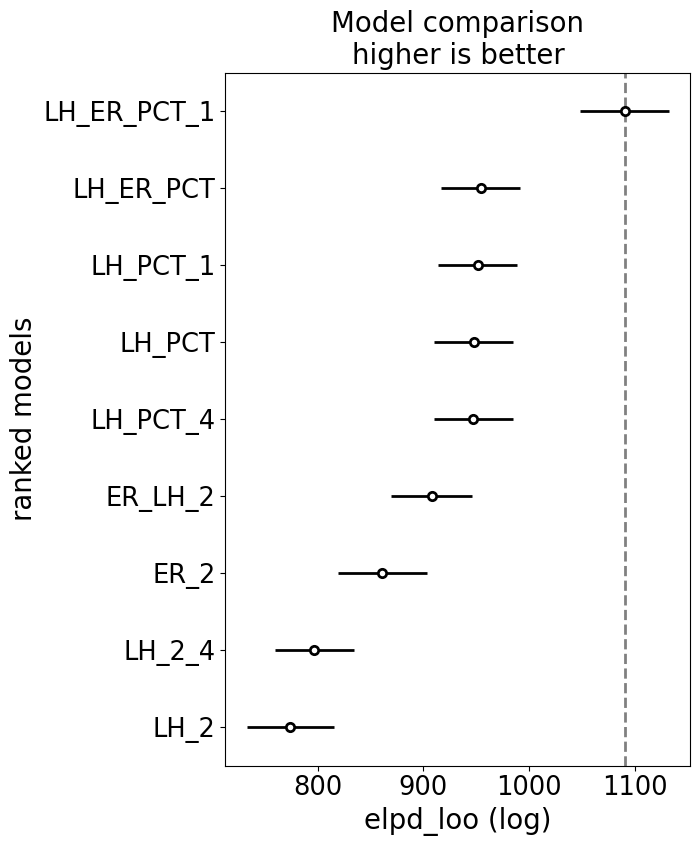

In [21]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2, 
    "ER_LH_2": loo_ER_LH_2,
    "LH_2_4": loo_LH_2_4,
    "LH_PCT": loo_LH_PCT,
    "LH_ER_PCT": loo_LH_ER_PCT,
    "LH_PCT_4": loo_LH_PCT_4,
    "LH_PCT_1": loo_LH_PCT_1, 
    "LH_ER_PCT_1": loo_LH_ER_PCT_1
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()